In [1]:
import sys
sys.path.append('./Textual-Anomaly-Detection-Framework/Anomaly Detection Framework')

from Data_Preparation.Embedding import embedding_encoder
from Data_Preparation.Tac import tac
from Data_Preparation import utils
from Modelisation.FlowMatching import flow_matching
from Modelisation.Baselines.OCSVM.ocsvm import OCSVM
from Modelisation.Baselines.CVDD.utils import build_vocab, cvdd_model_pipeline
import Modelisation.evaluation as ev
from Modelisation.Baselines.CVDD.networks import cvdd_Net
# from Modelisation.Baselines.RSRAE.model import CAE
from Modelisation.Baselines.TCCM.model import *
from utils import save_results, create_tables, save_hyperparameters, load_hyperparams, get_data_fasttext, load_data_test, load_data_inlier
from Modelisation.Baselines.RSRAE.model import RSRAE
from Modelisation.Baselines.AE.autoencoder import AE
from Modelisation.Baselines.TCCM.model import TCCM
from Modelisation.FlowMatching.flow_matching import BasicFlowMatching
import datasets
from datasets import concatenate_datasets

import torch
from torch import Tensor
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import optuna
import torch
from torch import nn, Tensor
import numpy as np
from transformers import AutoTokenizer
from datasets import Dataset, concatenate_datasets
import time
import tensorflow as tf
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from pyod.models.auto_encoder import AutoEncoder
import os

import warnings
warnings.filterwarnings('ignore')

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

2025-12-19 10:45:50.518873: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Device: cuda


In [2]:
%load_ext autoreload
%autoreload 2

In [240]:
# train_20ng_, test_20ng_ = utils.import_dataset(name="20newsgroups", batch_size=BATCH_SIZE)
# train_reuters_, test_reuters_ = utils.import_dataset(name="reuters", batch_size=BATCH_SIZE)
# # train_wos = utils.import_dataset(name="WOS", batch_size=BATCH_SIZE)
train_dbpedia14_, test_dbpedia14_ = utils.import_dataset(name="dbpedia14", batch_size=BATCH_SIZE)
# train_agnews_, test_agnews_ = utils.import_dataset(name="agnews", batch_size=BATCH_SIZE)

dbpedia14 dataset importing .... 




In [241]:
# train_agnews_ = utils.preprocess(train_agnews_.dataset)
# test_agnews_ = utils.preprocess(test_agnews_.dataset)

# train_reuters_ = utils.preprocess(train_reuters_.dataset)
# test_reuters_ = utils.preprocess(test_reuters_.dataset)

# train_20ng_ = utils.preprocess(train_20ng_.dataset)
# test_20ng_ = utils.preprocess(test_20ng_.dataset)

train_dbpedia14_ = utils.preprocess(train_dbpedia14_.dataset)
test_dbpedia14_ = utils.preprocess(test_dbpedia14_.dataset)

In [3]:
# model_name = 'all-MiniLM-L6-v2'
model_name = 'all-distilroberta-v1'
sentencebertEncoder = embedding_encoder.EmbeddingEncoder(model_name, 'sentencebert', device)

In [3]:
def train_test_val_split(train, test, inlier_topic, dataset_name, type_tac, anomaly_rate, train_infected=False, verbose=False):
    
    train_inlier, train_anomaly = tac.textual_anomaly_contamination(train, dataset_name, inlier_topic, type_tac, anomaly_rate, True)

    if train_infected:
        train_inlier = concatenate_datasets([train_inlier, train_anomaly]).shuffle(42)

    n_inliers_val = int(0.1 * len(train_inlier))
    inlier_indices = np.random.choice(len(train_inlier), n_inliers_val, replace=False)
    val_inlier_dataset = train_inlier.select(inlier_indices)

    train_inlier = train_inlier.select([i for i in range(len(train_inlier)) if i not in inlier_indices])
    
    n_anomalies_val = int(n_inliers_val / 0.9 * 0.1)
    anomaly_indices = np.random.choice(len(train_anomaly), n_anomalies_val, replace=False)
    val_anomaly_dataset = train_anomaly.select(anomaly_indices)

    val_ = concatenate_datasets([val_inlier_dataset, val_anomaly_dataset]).shuffle(seed=42)
    
    if verbose:
        print("TRAINSET")
        print(train_inlier)
        print(train_anomaly)
    
    if verbose:
        print("\nVALSET")
        print(val_)
        print()

    test_ = tac.textual_anomaly_contamination(test, dataset_name, inlier_topic, type_tac, anomaly_rate, False)
    if verbose:
        print("TESTSET")
        print(test_)

    return train_inlier, train_anomaly, val_, test_

def get_embeddings(sentencebertEncoder, train_reuters_, test_reuters_, inlier_topic, dataset_name, type_tac, anomaly_rate, device, hm='all',is_infec=False, text_column='text'):

    train_inlier_reuters, train_anomaly_reuters, val_reuters, test_reuters = train_test_val_split(train_reuters_, test_reuters_, inlier_topic, dataset_name, type_tac, anomaly_rate, is_infec, False)

    if hm == 'cvdd':
        return train_inlier_reuters, train_anomaly_reuters, val_reuters, test_reuters

    if hm == 'all':
        train_inlier_reuters = sentencebertEncoder.forward(train_inlier_reuters, text_column)
        test_reuters = sentencebertEncoder.forward(test_reuters, text_column)
        X_inlier = Tensor(train_inlier_reuters['sbert_embeddings']).to(device)
        X_test =  Tensor(test_reuters['sbert_embeddings']).to(device)
        y_test = np.array(test_reuters['anomaly_class'])

        return train_inlier_reuters, test_reuters, X_inlier, X_test, y_test
    
    elif hm == 'train':
        train_inlier_reuters = sentencebertEncoder.forward(train_inlier_reuters, text_column)
        X_inlier = Tensor(train_inlier_reuters['sbert_embeddings']).to(device)
        
        
        return train_inlier_reuters, _, X_inlier, _, _
    
    elif hm == 'test':
        test_reuters = sentencebertEncoder.forward(test_reuters, text_column)
        X_test =  Tensor(test_reuters['sbert_embeddings']).to(device)
        y_test = np.array(test_reuters['anomaly_class'])
        
        return _, test_reuters, _, X_test, y_test 


In [ ]:
nu_s = np.linspace(0.1,0.9,9)
auc_s = []
fpr95_s = []
ap_s = []
auc_s_ocvsm = []
fpr95_s_ocvsm = []
ap_s_ocvsm = []

for nu in nu_s:

    train_20ng_, test_20ng_ = utils.import_dataset(name="20newsgroups", batch_size=BATCH_SIZE)

    train_20ng_ = utils.preprocess(train_20ng_.dataset)
    test_20ng_ = utils.preprocess(test_20ng_.dataset)

    dataset_name = "20newsgroups"
    inlier_topic = "computer"
    type_tac = "ruff"
    anomaly_rate = nu

    train_inlier_reuters, test_reuters, X_inlier, X_test, y_test = get_embeddings(sentencebertEncoder, train_20ng_, test_20ng_, inlier_topic, dataset_name, type_tac, anomaly_rate, device, hm='all', text_column='text')


    batch_size = 32
    # batch_size = study.best_params['batch_size']
    X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

    input_dim = X_inlier.shape[1]
    latent_dim = 256
    sinu = False
    batchnorm = False
    dropout = 0.1
    lr = 1e-4
    # lr = study.best_params['lr']
    weight_decay = 1e-6
    # weight_decay = study.best_params['weight_decay']
    n_epochs = 50
    # n_epochs = study.best_params['n_epochs']


    target = X_inlier.cpu()
    source = 'sphere'
    # source = study.best_params['source']


    flow_model = flow_matching.FlowMatching(source, target, input_dim, latent_dim, sinu, dropout, batchnorm, device).to(device)
    optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    fm_trainer = flow_matching.FlowMatchingTrainer(flow_model, verbose=True)

    taac = time.time()

    flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

    tiic = time.time()

    print(f"\nFM finishing... after {(tiic-taac)/60:.3f} mn")

    auc, fpr95, ap = fm_trainer.test(X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10)
    auc_s.append(auc)
    fpr95_s.append(fpr95)
    ap_s.append(ap)
    print()

    ocsvm_args = {
        "nu": 0.1,
        "kernel": 'rbf',
        "gamma": 'scale'
        }

    ocsvm_model = OCSVM(ocsvm_args)

    taac = time.time()
    _ = ocsvm_model.train(X_inlier.cpu())
    tiic = time.time()
    print(f"\nOCSVM finishing... after {(tiic-taac)/60:.3f} mn")

    auc_ocsvm, fpr95_ocsvm, ap_ocsvm = ocsvm_model.test(X_test.cpu(), y_test)
    print(f"OCSVM --> AUC: {auc_ocsvm:.4f} | FPR@95: {fpr95_ocsvm:.4f} | AP: {ap_ocsvm:.4f}\n")

    auc_s_ocvsm.append(auc_ocsvm)
    fpr95_s_ocvsm.append(fpr95_ocsvm)
    ap_s_ocvsm.append(ap_ocsvm)


20newsgroups dataset importing .... 




Repo card metadata block was not found. Setting CardData to empty.


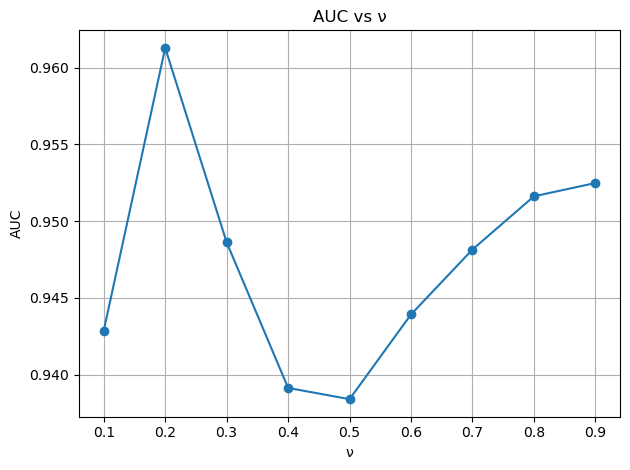

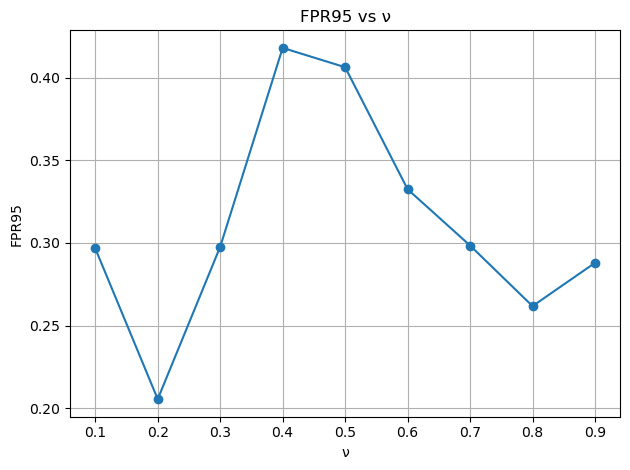

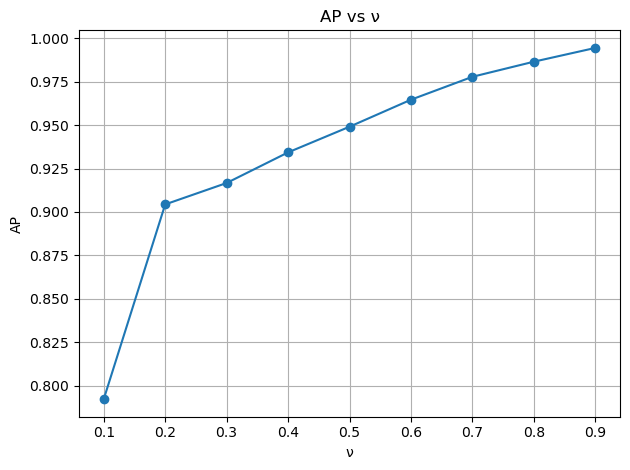

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Exemple de vecteur nu_s
nu_s = np.linspace(0.1, 0.9, 9)

# --- Plot AUC vs ν ---
plt.figure()
plt.plot(nu_s, auc_s, marker='o')
plt.plot(nu_s, auc_s_ocvsm, marker='o')
plt.xlabel("ν")
plt.ylabel("AUC")
plt.title("AUC vs ν")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot FPR95 vs ν ---
plt.figure()
plt.plot(nu_s, fpr95_s, marker='o')
plt.plot(nu_s, fpr95_s_ocvsm, marker='o')
plt.xlabel("ν")
plt.ylabel("FPR95")
plt.title("FPR95 vs ν")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot AP vs ν ---
plt.figure()
plt.plot(nu_s, ap_s, marker='o')
plt.plot(nu_s, ap_s_ocvsm, marker='o')
plt.xlabel("ν")
plt.ylabel("AP")
plt.title("AP vs ν")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
X_inlier.shape, X_test.shape, y_test.shape

(torch.Size([512, 768]), torch.Size([379, 768]), (379,))

In [ ]:
ocsvm_args = {
        "nu": 0.1,
        "kernel": 'rbf',
        "gamma": 'scale'
        }

ocsvm_model = OCSVM(ocsvm_args)

taac = time.time()
_ = ocsvm_model.train(X_inlier.cpu())
tiic = time.time()
print(f"\nOCSVM finishing... after {(tiic-taac)/60:.3f} mn")

auc_ocsvm, fpr95_ocsvm, ap_ocsvm = ocsvm_model.test(X_test.cpu(), y_test)
print(f"OCSVM --> AUC: {auc_ocsvm:.4f} | FPR@95: {fpr95_ocsvm:.4f} | AP: {ap_ocsvm:.4f}\n")


OCSVM finishing... after 0.001 mn
OCSVM --> AUC: 0.6370 | FPR@95: 0.1354 | AP: 0.8509



In [ ]:
ae_args = {
    "contamination": 0.1,
    "hidden_neuron_list": [32, 16],
    "hidden_activation_name": "relu",
    "epoch_num": 5,
    "batch_size": 64,
    "dropout_rate": 0.0,
    "verbose": 0
}


ae_model = AE(ae_args)

taac = time.time()
_ = ae_model.train(X_inlier)
tiic = time.time()
print(f"\nAE finishing... after {(tiic-taac)/60:.3f} mn")

auc_ae, fpr95_ae, ap_ae = ae_model.test(X_test, y_test)
print(f"AE --> AUC: {auc_ae:.4f} | FPR@95: {fpr95_ae:.4f} | AP: {ap_ae:.4f}\n")



AE finishing... after 0.002 mn
AE --> AUC: 0.6907 | FPR@95: 0.1553 | AP: 0.7690



In [ ]:
for _ in range(3):

    batch_size = 64
    # batch_size = study.best_params['batch_size']
    X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

    input_dim = X_inlier.shape[1]
    latent_dim = 256
    sinu = False
    batchnorm = False
    dropout = 0.1
    lr = 1e-3
    # lr = study.best_params['lr']
    weight_decay = 1e-4
    # weight_decay = study.best_params['weight_decay']
    n_epochs = 10
    # n_epochs = study.best_params['n_epochs']


    target = X_inlier.cpu()
    source = 'sphere'
    # source = study.best_params['source']


    flow_model = flow_matching.FlowMatching(source, target, input_dim, latent_dim, sinu, dropout, batchnorm, device).to(device)
    optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    fm_trainer = flow_matching.FlowMatchingTrainer(flow_model, verbose=True)

    taac = time.time()

    flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

    tiic = time.time()

    print(f"\nFM finishing... after {(tiic-taac)/60:.3f} mn")

    auc, fpr95, ap = fm_trainer.test(X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10)

 step 0 -> loss : 0.00256
 step 2 -> loss : 0.00247
 step 4 -> loss : 0.00240
 step 6 -> loss : 0.00238
 step 8 -> loss : 0.00241

FM finishing... after 0.003 mn
FM --> AUC: 0.6948 | FPR@95: 0.6784 | AP: 0.1569
 step 0 -> loss : 0.00261
 step 2 -> loss : 0.00242
 step 4 -> loss : 0.00244
 step 6 -> loss : 0.00242
 step 8 -> loss : 0.00242

FM finishing... after 0.003 mn
FM --> AUC: 0.6821 | FPR@95: 0.7105 | AP: 0.1504
 step 0 -> loss : 0.00258
 step 2 -> loss : 0.00247
 step 4 -> loss : 0.00240
 step 6 -> loss : 0.00239
 step 8 -> loss : 0.00242

FM finishing... after 0.003 mn
FM --> AUC: 0.6872 | FPR@95: 0.6871 | AP: 0.1533


### Saving data

In [ ]:
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"

dataset_name = '20newsgroups'
type_tac = 'ruff' 
anomaly_rate = 0.1

inlier_topics = ['computer', 'recreation', 'science', 'miscellaneous', 'politics', 'religion']

for inlier_topic in inlier_topics:
    
    save_path_temp = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}")
    os.makedirs(save_path_temp, exist_ok=True)
                                 
    save_path = os.path.join(save_path_temp, f"ds_train_{inlier_topic}.pt")
    save_path_cvdd = os.path.join(save_path_temp, f"ds_train_{inlier_topic}_cvdd.pt")
    
    if os.path.exists(save_path) and os.path.exists(save_path_cvdd) :
        print(f"{save_path} already done")
    else:
        train_data, _, X_inlier, _, _ = get_embeddings(sentencebertEncoder, train_20ng_, test_20ng_, inlier_topic, dataset_name, type_tac, anomaly_rate, device, 'train', False, 'text')    
        print(f"data saved at : {save_path}")
        if not os.path.exists(save_path) : torch.save({"X_inlier": X_inlier}, save_path)
        if not os.path.exists(save_path_cvdd) : train_data.save_to_disk(save_path_cvdd)

data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups/computer/ds_train_computer.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups/recreation/ds_train_recreation.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups/science/ds_train_science.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups/miscellaneous/ds_train_miscellaneous.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups/politics/ds_train_politics.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups/religion/ds_train_religion.pt


In [ ]:
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"

dataset_name = '20newsgroups'
type_tac = 'ruff' 
anomaly_rate = 0.1

inlier_topics = ['computer', 'recreation', 'science', 'miscellaneous', 'politics', 'religion']
nb_runs = 10

for run in range(nb_runs):

    for inlier_topic in inlier_topics:

        save_path_temp = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}/run{run+1}")
        os.makedirs(save_path_temp, exist_ok=True)

        save_path = os.path.join(save_path_temp, f"ds_test_{inlier_topic}_run{run+1}.pt")
        save_path_cvdd = os.path.join(save_path_temp, f"ds_test_{inlier_topic}_cvdd_run{run+1}.pt")
             
        if os.path.exists(save_path) and os.path.exists(save_path_cvdd) :
            print(f"{save_path} already done")
        else:
            _, test_data, _, X_test, y_test = get_embeddings(sentencebertEncoder, train_20ng_, test_20ng_, inlier_topic, dataset_name, type_tac, anomaly_rate, device, 'test', False, 'text')
            print(f"data saved at : {save_path}")
            if not os.path.exists(save_path) : torch.save({"X_test": X_test, "y_test": y_test}, save_path)
            if not os.path.exists(save_path_cvdd) : test_data.save_to_disk(save_path_cvdd)

data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups/computer/run1/ds_test_computer_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups/recreation/run1/ds_test_recreation_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups/science/run1/ds_test_science_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups/miscellaneous/run1/ds_test_miscellaneous_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups/politics/run1/ds_test_politics_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups/religion/run1/ds_test_religion_run1.pt
data saved at : /home/201702

In [ ]:
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"

dataset_name = 'reuters'
type_tac = 'ruff' 
anomaly_rate = 0.1

inlier_topics = ['acq', 'earn', 'trade', 'crude', 'interest', 'money-fx', 'ship']

for inlier_topic in inlier_topics:
    
    save_path_temp = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}")
    os.makedirs(save_path_temp, exist_ok=True)
                                 
    save_path = os.path.join(save_path_temp, f"ds_train_{inlier_topic}.pt")
    save_path_cvdd = os.path.join(save_path_temp, f"ds_train_{inlier_topic}_cvdd.pt")
    
    if os.path.exists(save_path) and os.path.exists(save_path_cvdd):
        print(f"{save_path} already done")
    else:
        train_data, _, X_inlier, _, _ = get_embeddings(sentencebertEncoder, train_reuters_, test_reuters_, inlier_topic, dataset_name, type_tac, anomaly_rate,  device, 'train', False, 'text')
        print(f"data saved at : {save_path}")
        if not os.path.exists(save_path) : torch.save({"X_inlier": X_inlier}, save_path)
        if not os.path.exists(save_path_cvdd) : train_data.save_to_disk(save_path_cvdd)

data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/acq/ds_train_acq.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/earn/ds_train_earn.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/trade/ds_train_trade.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/crude/ds_train_crude.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/interest/ds_train_interest.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/money-fx/ds_train_money-fx.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/ship/ds_train_ship.pt


In [ ]:
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"

dataset_name = 'reuters'
type_tac = 'ruff' 
anomaly_rate = 0.1

inlier_topics = ['acq', 'earn', 'trade', 'crude', 'interest', 'money-fx', 'ship']
nb_runs = 10

for run in range(nb_runs):

    for inlier_topic in inlier_topics:

        save_path_temp = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}/run{run+1}")
        os.makedirs(save_path_temp, exist_ok=True)

        save_path = os.path.join(save_path_temp, f"ds_test_{inlier_topic}_run{run+1}.pt")
        save_path_cvdd = os.path.join(save_path_temp, f"ds_test_{inlier_topic}_cvdd_run{run+1}.pt")
        
        if os.path.exists(save_path) and os.path.exists(save_path_cvdd):
            print(f"{save_path} already done")
        else:
            _, data_test, _, X_test, y_test = get_embeddings(sentencebertEncoder, train_reuters_, test_reuters_, inlier_topic, dataset_name, type_tac, anomaly_rate, device, 'test', False, 'text')
            print(f"data saved at : {save_path}")
            if not os.path.exists(save_path) : torch.save({"X_test": X_test, "y_test": y_test}, save_path)
            if not os.path.exists(save_path_cvdd) : data_test.save_to_disk(save_path_cvdd)

data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/acq/run1/ds_test_acq_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/earn/run1/ds_test_earn_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/trade/run1/ds_test_trade_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/crude/run1/ds_test_crude_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/interest/run1/ds_test_interest_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/money-fx/run1/ds_test_money-fx_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framewo

In [119]:
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"

dataset_name = 'agnews'
type_tac = 'fate' 
anomaly_rate = 0.1

inlier_topics = ['World', 'Sports', 'Business', 'Sci/Tech']

for inlier_topic in inlier_topics:
    
    if inlier_topic == 'Sci/Tech':
        inlier_topic = 'Sci-Tech'
    
    save_path_temp = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}")
    
    os.makedirs(save_path_temp, exist_ok=True)
                                 
    save_path = os.path.join(save_path_temp, f"ds_train_{inlier_topic}.pt")
    save_path_cvdd = os.path.join(save_path_temp, f"ds_train_{inlier_topic}_cvdd.pt")
    
    if os.path.exists(save_path) and os.path.exists(save_path_cvdd):
        print(f"{save_path} already done")
    else:
        if inlier_topic == 'Sci-Tech' :
            inlier_topic = 'Sci/Tech'
        train_data, _, X_inlier, _, _ = get_embeddings(sentencebertEncoder, train_agnews_, test_agnews_, inlier_topic, dataset_name, type_tac, anomaly_rate,  device, 'train', False, 'text')
        print(f"data saved at : {save_path}")
        if not os.path.exists(save_path) : torch.save({"X_inlier": X_inlier}, save_path)
        if not os.path.exists(save_path_cvdd) : train_data.save_to_disk(save_path_cvdd)

data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/agnews/World/ds_train_World.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/agnews/Sports/ds_train_Sports.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/agnews/Business/ds_train_Business.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/agnews/Sci-Tech/ds_train_Sci-Tech.pt


In [120]:
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"

dataset_name = 'agnews'
type_tac = 'fate' 
anomaly_rate = 0.1

inlier_topics = ['World', 'Sports', 'Business', 'Sci/Tech']
nb_runs = 10

for run in range(nb_runs):

    for inlier_topic in inlier_topics:
        
        if inlier_topic == 'Sci/Tech':
            inlier_topic = 'Sci-Tech'

        save_path_temp = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}/run{run+1}")
        os.makedirs(save_path_temp, exist_ok=True)

        save_path = os.path.join(save_path_temp, f"ds_test_{inlier_topic}_run{run+1}.pt")
        save_path_cvdd = os.path.join(save_path_temp, f"ds_test_{inlier_topic}_cvdd_run{run+1}.pt")
        
        if os.path.exists(save_path) and os.path.exists(save_path_cvdd):
            print(f"{save_path} already done")
        else:
            if inlier_topic == 'Sci-Tech' :
                inlier_topic = 'Sci/Tech'
            _, data_test, _, X_test, y_test = get_embeddings(sentencebertEncoder, train_agnews_, test_agnews_, inlier_topic, dataset_name, type_tac, anomaly_rate, device, 'test', False, 'text')
            print(f"data saved at : {save_path}")
            if not os.path.exists(save_path) : torch.save({"X_test": X_test, "y_test": y_test}, save_path)
            if not os.path.exists(save_path_cvdd) : data_test.save_to_disk(save_path_cvdd)

data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/agnews/World/run1/ds_test_World_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/agnews/Sports/run1/ds_test_Sports_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/agnews/Business/run1/ds_test_Business_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/agnews/Sci-Tech/run1/ds_test_Sci-Tech_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/agnews/World/run2/ds_test_World_run2.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/agnews/Sports/run2/ds_test_Sports_run2.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Fra

In [258]:
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"

dataset_name = 'dbpedia14'
type_tac = 'pantin' 
anomaly_rate = 0.1

inlier_topics = ["Company", "Educational Institution", "Artist", "Athlete", "Office Holder", "Mean Of Transportation", "Building", "Natural Place", "Village", "Animal", "Plant", "Album", "Film", "Written Work"]
# inlier_topics = ["organization", "people", "transport", "construction", "places", "media"]

for inlier_topic in inlier_topics:
    
    save_path_temp = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}")
    os.makedirs(save_path_temp, exist_ok=True)
                                 
    # save_path = os.path.join(save_path_temp, f"ds_train_{inlier_topic}.pt")
    save_path_cvdd = os.path.join(save_path_temp, f"ds_train_{inlier_topic}_cvdd.pt")
    
    if os.path.exists(save_path_cvdd):
        print(f"{save_path_cvdd} already done")
    else:
        data_train, _, X_inlier, _, _ = get_embeddings(sentencebertEncoder, train_dbpedia14_, test_dbpedia14_, inlier_topic, dataset_name, type_tac, anomaly_rate, device, 'train', False, 'content')
        print(f"data saved at : {save_path_cvdd}")
        data_train.save_to_disk(save_path_cvdd)

/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/dbpedia14/Company/ds_train_Company_cvdd.pt already done
/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/dbpedia14/Educational Institution/ds_train_Educational Institution_cvdd.pt already done
/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/dbpedia14/Artist/ds_train_Artist_cvdd.pt already done
[2, 4, 9, 10]
[2, 4, 9, 10]
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/dbpedia14/Athlete/ds_train_Athlete_cvdd.pt
[2, 3, 9, 10]
[2, 3, 9, 10]
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/dbpedia14/Office Holder/ds_train_Office Holder_cvdd.pt


OSError: [Errno 122] Disk quota exceeded

In [ ]:
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"

dataset_name = 'dbpedia14'
type_tac = 'pantin' 
anomaly_rate = 0.1

inlier_topics = ["Company", "Educational Institution", "Artist", "Athlete", "Office Holder", "Mean Of Transportation", "Building", "Natural Place", "Village", "Animal", "Plant", "Album", "Film", "Written Work"]
# inlier_topics = ["organization", "people", "transport", "construction", "places", "media"]
nb_runs = 10

for run in range(nb_runs):

    for inlier_topic in inlier_topics:

        save_path_temp = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}/run{run+1}")
        os.makedirs(save_path_temp, exist_ok=True)

        save_path = os.path.join(save_path_temp, f"ds_test_{inlier_topic}_cvdd_run{run+1}.pt")
        
        if os.path.exists(save_path):
            print(f"{save_path} already done")
        else:
            _, data_test, _, X_test, y_test = get_embeddings(sentencebertEncoder, train_dbpedia14_, test_dbpedia14_, inlier_topic, dataset_name, type_tac, anomaly_rate, device, 'test', 'content')
            print(f"data saved at : {save_path}")
            data_train.save_to_disk(save_path)

data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/dbpedia14/organization/run1/ds_test_organization_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/dbpedia14/people/run1/ds_test_people_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/dbpedia14/transport/run1/ds_test_transport_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/dbpedia14/construction/run1/ds_test_construction_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/dbpedia14/places/run1/ds_test_places_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/dbpedia14/media/run1/ds_test_media_run1.pt
data saved at : /home/2017025/ayouce01/Textual-Anomaly

In [ ]:
# # import os
# # import shutil

# # save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/20newsgroups"

# # targets = ['computer', 'recreation', 'science', 'miscellaneous', 'politics', 'religion']

# # for name in targets:
# #     path = os.path.join(save_dir, name)

# #     if os.path.exists(path):
# #         # Si c'est un dossier → suppression récursive
# #         if os.path.isdir(path):
# #             print(f"Suppression du dossier : {path}")
# #             shutil.rmtree(path)

# #         # Si c'est un fichier → suppression simple
# #         elif os.path.isfile(path):
# #             print(f"Suppression du fichier : {path}")
# #             os.remove(path)
# #     else:
# #         print(f"{path} n'existe pas")

# import shutil
# import os

# path = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data_org"

# if os.path.exists(path):
#     shutil.rmtree(path)


import os
import shutil

save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/dbpedia14"
# targets = ['computer', 'recreation', 'science', 'miscellaneous', 'politics', 'religion']
# targets = ['acq', 'earn', 'trade', 'crude', 'interest', 'money-fx', 'ship']
targets = ["Company", "Educational Institution", "Artist", "Athlete", "Office Holder"]

for target in targets:
    print(f"\n--- Traitement target : {target} ---")

    for k in range(1, 11):  # run1 → run10
        run_folder = os.path.join(save_dir, target, f"run{k}")
        file_name = f"ds_train_{target}_cvdd.pt"
        file_path = os.path.join(run_folder, file_name)

        if os.path.exists(file_path):
            if os.path.isfile(file_path):
                print(f"Suppression du fichier : {file_path}")
                os.remove(file_path)
            elif os.path.isdir(file_path):
                print(f"Suppression du dossier (au lieu du fichier) : {file_path}")
                shutil.rmtree(file_path)
        else:
            print(f"Fichier introuvable : {file_path}")


--- Traitement target : acq ---
Suppression du fichier : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/acq/run1/ds_test_acq_run1.pt
Suppression du fichier : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/acq/run2/ds_test_acq_run2.pt
Suppression du fichier : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/acq/run3/ds_test_acq_run3.pt
Suppression du fichier : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/acq/run4/ds_test_acq_run4.pt
Suppression du fichier : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/acq/run5/ds_test_acq_run5.pt
Suppression du fichier : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data/reuters/acq/run6/ds_test_acq_run6.pt
Suppression du fichier : /home/2017025/ayou

### Loading Data

In [4]:
def load_data_inlier(dataset_name, inlier_topic, save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data", is_infec=False, is_cvdd=False):

    if is_cvdd:
        path = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}/ds_train_{inlier_topic}_cvdd.pt")
    else:
        if is_infec:
            path = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}/ds_train_{inlier_topic}_infec.pt")
        else:
            path = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}/ds_train_{inlier_topic}.pt")

    if not is_cvdd : return torch.load(path)['X_inlier']
    else: return datasets.load_from_disk(path)

def load_data_test(dataset_name, inlier_topic, n_run, save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data",is_cvdd=False):

    if is_cvdd:
        path = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}/run{n_run}/ds_test_{inlier_topic}_cvdd_run{n_run}.pt")
        return datasets.load_from_disk(path)
    else:
        path = os.path.join(save_dir, f"{dataset_name}/{inlier_topic}/run{n_run}/ds_test_{inlier_topic}_run{n_run}.pt")
        ds = torch.load(path)      
        return ds['X_test'], ds['y_test'] 


In [257]:
inlier_topic = 'Company'
dataset_name = 'dbpedia14'
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 1

# X_inlier = load_data_inlier(dataset_name, inlier_topic, save_dir)
# X_inlier_anoma = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=True)
data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
print(data_train)
# X_test, y_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir)
# data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)


Dataset({
    features: ['label', 'title', 'content', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 36000
})


In [ ]:
print(X_inlier.shape, X_inlier_anoma.shape, X_test.shape, y_test.shape)
print(data_train)
print(data_test)

torch.Size([2074, 768]) torch.Size([2304, 768]) torch.Size([1530, 768]) (1530,)
Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 2074
})
Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 1530
})


In [ ]:
data_train

Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 2576
})

In [ ]:
from sklearn.metrics.pairwise import pairwise_distances

ocsvm_kwargs = {
        "nu": 0.1,
        "kernel": 'rbf',
        # "gamma": 1 / (np.max(pairwise_distances(X_inlier.cpu())) ** 2)
        "gamma": 'scale'
        }
clf, _, _ = ocsvm.One_Class_SVM(X_inlier.cpu().detach(), ocsvm_kwargs)

_ = clf.predict(X_test.cpu().detach())           
scores_test = clf.decision_function(X_test.cpu().detach())

auc, ap, fpr95 = ev.evaluation(y_test, scores_test, verbose=False)
print(f"OCSVM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")

OCSVM --> AUC: 0.9228 | FPR@95: 0.3670 | AP: 0.6335


In [ ]:
clf = fit_ae(X_inlier)
test_ae(X_test, y_test, clf)

# cae = fit_rsrae(X_inlier)
# auc, fpr95, ap = test_rsrae(X_test, y_test, cae)

AE --> AUC: 0.9339 | FPR@95: 0.3088 | AP: 0.6611


(0.9339181286549707, 0.3087719298245614, 0.6610852769648258)

In [ ]:
tccm = fit_tccm(X_inlier)
auc, fpr95, ap = test_tccm(X_test, y_test, tccm)

TCCM --> AUC: 0.9779 | FPR@95: 0.0602 | AP: 0.9218


In [ ]:
for _ in range(1):

    batch_size = 256
    # batch_size = study.best_params['batch_size']
    X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

    input_dim = X_inlier.shape[1]
    latent_dim = 256
    sinu = False
    batchnorm = False
    dropout = 0.1
    lr = 1e-4
    # lr = study.best_params['lr']
    weight_decay = 1e-7
    # weight_decay = study.best_params['weight_decay']
    n_epochs = 30
    # n_epochs = study.best_params['n_epochs']


    target = X_inlier.cpu()
    source = 'sphere-noised'
    # source = study.best_params['source']


    flow_model = flow_matching.FlowMatching(source, target, input_dim, latent_dim, sinu, dropout, batchnorm, device).to(device)
    optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    fm_trainer = flow_matching.FlowMatchingTrainer(flow_model, verbose=True)

    taac = time.time()

    flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

    tiic = time.time()

    print(f"\nFM finishing... after {(tiic-taac)/60:.3f} mn")

    auc, fpr95, ap = fm_trainer.test(X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=30)

 step 0 -> loss : 0.06420
 step 6 -> loss : 0.05694
 step 12 -> loss : 0.05421
 step 18 -> loss : 0.05296
 step 24 -> loss : 0.05289

FM finishing... after 0.338 mn
FM --> AUC: 0.9228 | FPR@95: 0.3433 | AP: 0.6243


In [ ]:
create_tables()

Lecture des fichiers dans chaque dataset...
Fichier LaTeX généré : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results/tables.tex


In [ ]:
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
file_path_hyp = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results/hyperparams.txt"

dataset_name = 'agnews'
# inlier_topics = ['computer','recreation', 'science', 'miscellaneous', 'politics', 'religion']
# inlier_topics = ['science', 'computer']
inlier_topics = ['World', 'Sports', 'Business', 'Sci-Tech']
# inlier_topics = ['earn', 'trade', 'acq', 'money-fx', 'crude', 'ship', 'interest']
# inlier_topics = ['acq', 'money-fx', 'crude', 'ship', 'interest']


for inlier_topic in inlier_topics:
    
    list_auc_fm = []
    list_fpr_fm = []
    list_ap_fm = []
    list_time_fm = []

    list_auc_ocsvm = []
    list_fpr_ocsvm = []
    list_ap_ocsvm = []
    list_time_ocsvm = []

    list_auc_rsrae = []
    list_fpr_rsrae = []
    list_ap_rsrae = []
    list_time_rsrae = []

    list_auc_ae = []
    list_fpr_ae = []
    list_ap_ae = []
    list_time_ae = []
    
    list_auc_tccm = []
    list_fpr_tccm = []
    list_ap_tccm = []
    list_time_tccm = []
        
    # print("---------------------------------")
    # print(f"-----------{inlier_topic}------------")
    # print("---------------------------------\n")
     
    X_inlier = load_data_inlier(dataset_name, inlier_topic, save_dir)
    hyp = load_hyperparams(dataset_name, inlier_topic, file_path_hyp)
    
    for n_run in range(1,11):
        
        # print("///////////////////////////////")
        # print(f"////////Run {n_run}////////")
        # print("///////////////////////////////\n")
           
        ################################################
        ################# LOADING DATA #################
        ################################################  
        
        X_test, y_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir)
        
        #########################################
        ################# OCSVM #################
        #########################################  

        ocsvm_kwargs = {
            "nu": 0.1,
            "kernel": 'rbf',
            "gamma": 'scale'
            }
        
        taac = time.time()
        clf, _, _ = ocsvm.One_Class_SVM(X_inlier.cpu(), ocsvm_kwargs)
        tiic = time.time()

        print(f"OCSVM finishing... after {(tiic-taac)/60:.3f} mn")
        # list_time_ocsvm.append((tiic-taac)/60)

        _ = clf.predict(X_test.cpu().detach())           
        scores_test = clf.decision_function(X_test.cpu())

        auc_ocsvm, ap_ocsvm, fpr95_ocsvm = ev.evaluation(y_test, scores_test, verbose=False)
        # print(f"\nOCSVM --> AUC: {auc_ocsvm:.4f} | FPR@95: {fpr95_ocsvm:.4f} | AP: {ap_ocsvm:.4f}\n")

        list_auc_ocsvm.append(auc_ocsvm)
        list_fpr_ocsvm.append(fpr95_ocsvm)    
        list_ap_ocsvm.append(ap_ocsvm)
        list_time_ocsvm.append((tiic-taac))
        
        # #########################################
        # ################# RSRAE #################
        # #########################################  
        taac = time.time()
        cae = fit_rsrae(X_inlier)
        tiic = time.time()
        
        print(f"\nRSRAE finishing... after {(tiic-taac)/60:.3f} mn")
        list_time_rsrae.append((tiic-taac)/60)

        auc_rsrae, fpr95_rsrae, ap_rsrae = test_rsrae(X_test, y_test, cae)

        list_auc_rsrae.append(auc_rsrae)
        list_fpr_rsrae.append(fpr95_rsrae)    
        list_ap_rsrae.append(ap_rsrae) 
        list_time_rsrae.append((tiic-taac))

#         ######################################
#         ################# AE #################
#         ######################################
        taac = time.time()
        clf = fit_ae(X_inlier)
        tiic = time.time()
        
                
        # print(f"\nAE finishing... after {(tiic-taac)/60:.3f} mn")
        list_time_ae.append((tiic-taac)/60)
        
        auc_ae, fpr95_ae, ap_ae = test_ae(X_test, y_test, clf)

        list_auc_ae.append(auc_ae)
        list_fpr_ae.append(fpr95_ae)    
        list_ap_ae.append(ap_ae)  
        list_time_ae.append((tiic-taac))
        
#         #################################################
#         ################# Flow Matching #################
#         #################################################  
        
        # # batch_size = 2048
        # batch_size = hyp['batch_size']
        # # batch_size = study.best_params['batch_size']
        # X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

        # input_dim = X_inlier.shape[1]
        # # latent_dim = 256
        # latent_dim = hyp['latent_dim']
        # sinu = False
        # batchnorm = False
        # # dropout = 0.1
        # dropout = hyp['dropout']
        # # lr = 1e-1
        # lr = hyp['lr']
        # # lr = study.best_params['lr']
        # # weight_decay = 1e-3
        # weight_decay = hyp['weight_decay']
        # # weight_decay = study.best_params['weight_decay']
        # # n_epochs = 30
        # n_epochs = hyp['n_epochs']
        # # n_epochs = study.best_params['n_epochs']


        # target = X_inlier.cpu()
        # # source = 'sphere'
        # source = hyp['source']
        # # source = study.best_params['source']


        # flow_model = flow_matching.FlowMatching(source, target, input_dim, latent_dim, sinu, dropout, batchnorm, device).to(device)
        # optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
        # loss_fn = nn.MSELoss()

        # fm_trainer = flow_matching.FlowMatchingTrainer(flow_model, verbose=False)

        # taac = time.time()

        # flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

        # tiic = time.time()

        # # print(f"\nFM finishing... after {(tiic-taac)/60:.3f} mn")

        # auc, fpr95, ap = fm_trainer.test(X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10)
        
        # list_auc_fm.append(auc)
        # list_fpr_fm.append(fpr95)    
        # list_ap_fm.append(ap)
        # list_time_fm.append((tiic-taac))

        ########################################
        ################# TCCM #################
        ########################################  
        taac = time.time()
        tccm = fit_tccm(X_inlier)
        tiic = time.time()
        
        auc_tccm, fpr95_tccm, ap_tccm = test_tccm(X_test, y_test, tccm)
        
        list_auc_tccm.append(auc_tccm)
        list_fpr_tccm.append(fpr95_tccm)    
        list_ap_tccm.append(ap_tccm)  
        list_time_tccm.append((tiic-taac))  
        
    # print(inlier_topic ,np.mean(list_auc_fm))
    # save_results(
    #     dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="sentence_bert" ,ad_model="flow-matching",
    #     auc_mean=np.mean(list_auc_fm), ap_mean=np.mean(list_ap_fm),fpr_mean=np.mean(list_fpr_fm),
    #     auc_std = np.std(list_auc_fm),ap_std =  np.std(list_ap_fm),fpr_std = np.std(list_fpr_fm),
    #     train_time = np.mean(list_time_fm),overwrite='naive'
    #     )

        
    save_results(
        dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="sentence_bert" ,ad_model="AE",
        auc_mean=np.mean(list_auc_ae), ap_mean=np.mean(list_ap_ae),fpr_mean=np.mean(list_fpr_ae),
        auc_std = np.std(list_auc_ae),ap_std =  np.std(list_ap_ae),fpr_std = np.std(list_fpr_ae),
        train_time = np.array(list_time_ae)[np.array(list_time_ae) > 1].mean(),overwrite='naive'
        )

    save_results(
        dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="sentence_bert" ,ad_model="RSRAE",
        auc_mean=np.mean(list_auc_rsrae), ap_mean=np.mean(list_ap_rsrae),fpr_mean=np.mean(list_fpr_rsrae),
        auc_std = np.std(list_auc_rsrae),ap_std =  np.std(list_ap_rsrae),fpr_std = np.std(list_fpr_rsrae),
        train_time = np.array(list_time_rsrae)[np.array(list_time_rsrae) > 2].mean(), overwrite='naive'
    )

    save_results(
        dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="sentence_bert" ,ad_model="ocsvm",
        auc_mean=np.mean(list_auc_ocsvm), ap_mean=np.mean(list_ap_ocsvm),fpr_mean=np.mean(list_fpr_ocsvm),
        auc_std = np.std(list_auc_ocsvm),ap_std =  np.std(list_ap_ocsvm),fpr_std = np.std(list_fpr_ocsvm),
        train_time = np.array(list_time_ocsvm)[np.array(list_time_ocsvm) > 4].mean(), overwrite='naive'
    )

    save_results(
        dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="sentence_bert" ,ad_model="TCCM",
        auc_mean=np.mean(list_auc_tccm), ap_mean=np.mean(list_ap_tccm),fpr_mean=np.mean(list_fpr_tccm),
        auc_std = np.std(list_auc_tccm),ap_std =  np.std(list_ap_tccm),fpr_std = np.std(list_fpr_tccm),
        train_time = np.mean(list_time_tccm), overwrite='naive'
    )


OCSVM finishing... after 2.113 mn


I0000 00:00:1765200878.987448 2302825 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78725 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:48:00.0, compute capability: 8.0


 epoch 50/100 : loss = 0.955
 epoch 100/100 : loss = 0.955

RSRAE finishing... after 0.667 mn
RSRAE --> AUC: 0.9182 | FPR@95: 0.2363 | AP: 0.4679
AE --> AUC: 0.9352 | FPR@95: 0.1982 | AP: 0.5817
TCCM --> AUC: 0.9421 | FPR@95: 0.2240 | AP: 0.6344
OCSVM finishing... after 2.821 mn


I0000 00:00:1765201188.262719 2302825 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78725 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:48:00.0, compute capability: 8.0


 epoch 50/100 : loss = 0.955
 epoch 100/100 : loss = 0.955

RSRAE finishing... after 0.690 mn
RSRAE --> AUC: 0.9009 | FPR@95: 0.2713 | AP: 0.4395
AE --> AUC: 0.9186 | FPR@95: 0.3006 | AP: 0.5171
TCCM --> AUC: 0.9273 | FPR@95: 0.2801 | AP: 0.5698
OCSVM finishing... after 2.118 mn


...

I0000 00:00:1765206389.566516 2302825 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78725 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:48:00.0, compute capability: 8.0


 epoch 50/100 : loss = 0.954
 epoch 100/100 : loss = 0.954

RSRAE finishing... after 0.672 mn
RSRAE --> AUC: 0.9051 | FPR@95: 0.4380 | AP: 0.5747
AE --> AUC: 0.9363 | FPR@95: 0.2602 | AP: 0.6555
TCCM --> AUC: 0.9340 | FPR@95: 0.2737 | AP: 0.6737
OCSVM finishing... after 2.234 mn


I0000 00:00:1765206670.019801 2302825 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78725 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:48:00.0, compute capability: 8.0


 epoch 50/100 : loss = 0.954
 epoch 100/100 : loss = 0.954

RSRAE finishing... after 0.667 mn
RSRAE --> AUC: 0.8837 | FPR@95: 0.4865 | AP: 0.5349
AE --> AUC: 0.9135 | FPR@95: 0.4439 | AP: 0.6495


KeyboardInterrupt: 

In [ ]:
# save_results(
#     dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="sentence_bert" ,ad_model="flow-matching",
#     auc_mean=np.mean(list_auc_fm), ap_mean=np.mean(list_ap_fm),fpr_mean=np.mean(list_fpr_fm),
#     auc_std = np.std(list_auc_fm),ap_std =  np.std(list_ap_fm),fpr_std = np.std(list_fpr_fm),
#     train_time = np.mean(list_time_fm),overwrite='naive'
# )

save_results(
    dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="sentence_bert" ,ad_model="AE",
    auc_mean=np.mean(list_auc_ae), ap_mean=np.mean(list_ap_ae),fpr_mean=np.mean(list_fpr_ae),
    auc_std = np.std(list_auc_ae),ap_std =  np.std(list_ap_ae),fpr_std = np.std(list_fpr_ae),
    train_time = np.array(list_time_ae)[np.array(list_time_ae) > 1].mean(),overwrite='naive'
)

save_results(
    dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="sentence_bert" ,ad_model="RSRAE",
    auc_mean=np.mean(list_auc_rsrae), ap_mean=np.mean(list_ap_rsrae),fpr_mean=np.mean(list_fpr_rsrae),
    auc_std = np.std(list_auc_rsrae),ap_std =  np.std(list_ap_rsrae),fpr_std = np.std(list_fpr_rsrae),
    train_time = np.array(list_time_rsrae)[np.array(list_time_rsrae) > 2].mean(), overwrite='naive'
)

save_results(
    dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="sentence_bert" ,ad_model="ocsvm",
    auc_mean=np.mean(list_auc_ocsvm), ap_mean=np.mean(list_ap_ocsvm),fpr_mean=np.mean(list_fpr_ocsvm),
    auc_std = np.std(list_auc_ocsvm),ap_std =  np.std(list_ap_ocsvm),fpr_std = np.std(list_fpr_ocsvm),
    train_time = np.array(list_time_ocsvm)[np.array(list_time_ocsvm) > 4].mean(), overwrite='naive'
)

save_results(
    dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="sentence_bert" ,ad_model="TCCM",
    auc_mean=np.mean(list_auc_tccm), ap_mean=np.mean(list_ap_tccm),fpr_mean=np.mean(list_fpr_tccm),
    auc_std = np.std(list_auc_tccm),ap_std =  np.std(list_ap_tccm),fpr_std = np.std(list_fpr_tccm),
    train_time = np.mean(list_time_tccm), overwrite='naive'
)

create_tables()

# save_hyperparameters(dataset_name, inlier_topic,
#                          batch_size=2048,
#                          latent_dim=256,
#                          sinu=False,
#                          batchnorm=False,
#                          dropout=0.1,
#                          lr=1e-1,
#                          weight_decay=1e-3,
#                          n_epochs=30,
#                          target=X_inlier.shape,
#                          source='sphere',
#                          save_dir="Results")

In [ ]:
np.mean(list_auc_fm), np.mean(list_auc_ae), np.mean(list_auc_ocsvm), np.mean(list_auc_rsrae), np.mean(list_auc_tccm)

In [ ]:
create_tables()

Lecture des fichiers dans chaque dataset...
Fichier LaTeX généré : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results/tables.tex


In [ ]:
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
dataset_name = '20newsgroups'
inlier_topics = ['computer', 'recreation', 'science', 'miscellaneous', 'politics', 'religion']

for inlier_topic in inlier_topics:
    
    list_auc_fm = []
    list_fpr_fm = []
    list_ap_fm = []
    list_time_fm = []

    list_auc_ocsvm = []
    list_fpr_ocsvm = []
    list_ap_ocsvm = []
    list_time_ocsvm = []

    list_auc_rsrae = []
    list_fpr_rsrae = []
    list_ap_rsrae = []
    list_time_rsrae = []

    list_auc_ae = []
    list_fpr_ae = []
    list_ap_ae = []
    list_time_ae = []
    
    print("---------------------------------")
    print(f"-----------{inlier_topic}------------")
    print("---------------------------------\n")
    
    
    X_inlier = load_X_inlier(dataset_name, inlier_topic, save_dir)
    
    for n_run in range(1,11):
        
        print("///////////////////////////////")
        print(f"////////Run {n_run}////////")
        print("///////////////////////////////\n")
           
        ################################################
        ################# LOADING DATA #################
        ################################################  
        
        X_test, y_test = load_X_test(dataset_name, inlier_topic, n_run, save_dir)
        
        #########################################
        ################# OCSVM #################
        #########################################  

        ocsvm_kwargs = {
            "nu": 0.1,
            "kernel": 'rbf',
            "gamma": 'scale'
            }
        
        taac = time.time()
        clf, _, _ = ocsvm.One_Class_SVM(X_inlier.cpu(), ocsvm_kwargs)
        tiic = time.time()

        print(f"OCSVM finishing... after {(tiic-taac)/60:.3f} mn")
        list_time_ocsvm.append((tiic-taac)/60)

        _ = clf.predict(X_test.cpu().detach())           
        scores_test = clf.decision_function(X_test.cpu())

        auc_ocsvm, ap_ocsvm, fpr95_ocsvm = ev.evaluation(y_test, scores_test, verbose=False)
        print(f"\nOCSVM --> AUC: {auc_ocsvm:.4f} | FPR@95: {fpr95_ocsvm:.4f} | AP: {ap_ocsvm:.4f}\n")

        list_auc_ocsvm.append(auc_ocsvm)
        list_fpr_ocsvm.append(fpr95_ocsvm)    
        list_ap_ocsvm.append(ap_ocsvm)  
        
        #########################################
        ################# RSRAE #################
        #########################################  
        taac = time.time()
        cae = fit_rsrae(X_inlier)
        tiic = time.time()
        
        print(f"\nRSRAE finishing... after {(tiic-taac)/60:.3f} mn")
        list_time_rsrae.append((tiic-taac)/60)

        auc_rsrae, fpr95_rsrae, ap_rsrae = test_rsrae(X_test, y_test, cae)

        list_auc_rsrae.append(auc_rsrae)
        list_fpr_rsrae.append(fpr95_rsrae)    
        list_ap_rsrae.append(ap_rsrae)  


        ######################################
        ################# AE #################
        ######################################
        taac = time.time()
        clf = fit_ae(X_inlier)
        tiic = time.time()
        
                
        print(f"\nAE finishing... after {(tiic-taac)/60:.3f} mn")
        list_time_ae.append((tiic-taac)/60)
        
        auc_ae, fpr95_ae, ap_ae = test_ae(X_test, y_test, clf)

        list_auc_ae.append(auc_ae)
        list_fpr_ae.append(fpr95_ae)    
        list_ap_ae.append(ap_ae)  
        
    save_results(
    dataset_name=dataset_name,
    inlier_topic=inlier_topic,
    type_emb="sentence_bert",
    ad_model="RSRAE",
    auc_mean=np.mean(list_auc_rsrae),
    ap_mean=np.mean(list_ap_rsrae),
    fpr_mean=np.mean(list_fpr_rsrae),
    auc_std = np.std(list_auc_rsrae),
    ap_std =  np.std(list_ap_rsrae),
    fpr_std = np.std(list_fpr_rsrae),
    overwrite='naive'
)

    save_results(
        dataset_name=dataset_name,
        inlier_topic=inlier_topic,
        type_emb="sentence_bert",
        ad_model="AE",
        auc_mean=np.mean(list_auc_ae),
        ap_mean=np.mean(list_ap_ae),
        fpr_mean=np.mean(list_fpr_ae),
        auc_std = np.std(list_auc_ae),
        ap_std =  np.std(list_ap_ae),
        fpr_std = np.std(list_fpr_ae),
        overwrite='naive'
    )

    save_results(
        dataset_name=dataset_name,
        inlier_topic=inlier_topic,
        type_emb="sentence_bert",
        ad_model="ocsvm",
        auc_mean=np.mean(list_auc_ocsvm),
        ap_mean=np.mean(list_ap_ocsvm),
        fpr_mean=np.mean(list_fpr_ocsvm),
        auc_std = np.std(list_auc_ocsvm),
        ap_std =  np.std(list_ap_ocsvm),
        fpr_std = np.std(list_fpr_ocsvm),
        overwrite='naive'
    )


#         ################################################
#         ################ FLOW MATCHING #################
#         ################################################

#         batch_size = 512
#         # batch_size = study.best_params['batch_size']
#         X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

#         input_dim = X_inlier.shape[1]
#         latent_dim = 256
#         sinu = False
#         lr = 1e-4
#         # lr = study.best_params['lr']
#         weight_decay = 1e-4
#         # weight_decay = study.best_params['weight_decay']
#         n_epochs = 100
#         # n_epochs = study.best_params['n_epochs']


#         target = X_inlier.cpu()
#         source = 'sphere'
#         # source = study.best_params['source']


#         flow_model = flow_matching.FlowMatching(source, target, input_dim, latent_dim, sinu, device).to(device)
#         optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
#         loss_fn = nn.MSELoss()

#         fm_trainer = flow_matching.FlowMatchingTrainer(flow_model, verbose=True)

#         taac = time.time()

#         flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

#         tiic = time.time()

#         print(f"\nFM finishing... after {(tiic-taac)/60:.3f} mn")

#         auc, fpr95, ap = fm_trainer.test(X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10)

#         list_auc_fm.append(auc)
#         list_fpr_fm.append(fpr95)    
#         list_ap_fm.append(ap)
          


    

In [ ]:
create_tables()

Lecture des fichiers dans chaque dataset...
Fichier LaTeX généré : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results/tables.tex


### Investigation

In [ ]:
inlier_topic = 'acq'
dataset_name = 'reuters'
type_tac = 'ruff' 
anomaly_rate = 0.1

train_inlier_reuters_acq, test_reuters_acq, X_inlier_acq, X_test_acq, y_test_acq = get_embeddings(train_reuters_, test_reuters_, inlier_topic, dataset_name, type_tac, anomaly_rate)

In [ ]:
inlier_topic = 'crude'
dataset_name = 'reuters'
type_tac = 'ruff' 
anomaly_rate = 0.1

train_inlier_reuters_crude, test_reuters_crude, X_inlier_crude, X_test_crude, y_test_crude = get_embeddings(train_reuters_, test_reuters_, inlier_topic, dataset_name, type_tac, anomaly_rate)

In [ ]:
inlier_topic = 'earn'
dataset_name = 'reuters'
type_tac = 'ruff' 
anomaly_rate = 0.1

train_inlier_reuters_earn, test_reuters_earn, X_inlier_earn, X_test_earn, y_test_earn = get_embeddings(train_reuters_, test_reuters_, inlier_topic, dataset_name, type_tac, anomaly_rate)

In [ ]:
inlier_topic = 'ship'
dataset_name = 'reuters'
type_tac = 'ruff' 
anomaly_rate = 0.1

train_inlier_reuters_ship, test_reuters_ship, X_inlier_ship, X_test_ship, y_test_ship = get_embeddings(train_reuters_, test_reuters_, inlier_topic, dataset_name, type_tac, anomaly_rate)

In [ ]:
print(X_inlier_acq.mean())
print(X_inlier_crude.mean())
print(X_inlier_earn.mean())
print(X_inlier_ship.mean())

print()

print(X_inlier_acq.max())
print(X_inlier_crude.max())
print(X_inlier_earn.max())
print(X_inlier_ship.max())

print()

print(X_inlier_acq.min())
print(X_inlier_crude.min())
print(X_inlier_earn.min())
print(X_inlier_ship.min())

In [ ]:
X_embedded = TSNE(n_components=3, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X_inlier_acq.cpu())

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_embedded[:,0], X_embedded[:,1], X_embedded[:,2], color='crimson')

In [ ]:
X_embedded = TSNE(n_components=3, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X_inlier_crude.cpu())

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_embedded[:,0], X_embedded[:,1], X_embedded[:,2], color='crimson')

In [ ]:
X_embedded = TSNE(n_components=3, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X_inlier_earn.cpu())

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_embedded[:,0], X_embedded[:,1], X_embedded[:,2], color='crimson')

In [ ]:
X_embedded = TSNE(n_components=3, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X_inlier_ship.cpu())

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_embedded[:,0], X_embedded[:,1], X_embedded[:,2], color='crimson')

In [ ]:
z = torch.randn(1500, 384)
z = z / z.norm(dim=1, keepdim=True)
noise = torch.randn_like(z) * 0.25
X__ = Tensor(z + noise)

X_embedded = TSNE(n_components=3, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X__)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_embedded[:,0], X_embedded[:,1], X_embedded[:,2], color='crimson')

In [ ]:
target_centroid = X_inlier_acq.mean(dim=0).cpu()
target_cov_mat = torch.cov(X_inlier_acq.T).cpu()

eps = 1e-2
cov_reg = target_cov_mat + eps * torch.eye(target_cov_mat.size(0))

distri = torch.distributions.MultivariateNormal(target_centroid, covariance_matrix=cov_reg)
z = distri.sample((1500,))

z = z / z.norm(dim=1, keepdim=True)
noise = torch.randn_like(z) * 0.25
X__ = Tensor(z + noise)

X_embedded = TSNE(n_components=3, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X__)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_embedded[:,0], X_embedded[:,1], X_embedded[:,2], color='crimson')

In [ ]:
target_centroid = X_inlier_crude.mean(dim=0).cpu()
target_cov_mat = torch.cov(X_inlier_crude.T).cpu()

eps = 1e-2
cov_reg = target_cov_mat + eps * torch.eye(target_cov_mat.size(0))

distri = torch.distributions.MultivariateNormal(target_centroid, covariance_matrix=cov_reg)
z = distri.sample((1500,))

z = z / z.norm(dim=1, keepdim=True)
noise = torch.randn_like(z) * 0.25
X__ = Tensor(z + noise)

print(X__.mean())
print(X__.max())
print(X__.min())

print("-----------------")

z = torch.randn(1500, 384)
z = z / z.norm(dim=1, keepdim=True)
noise = torch.randn_like(z) * 0.25
X__ = Tensor(z + noise)

print(X__.mean())
print(X__.max())
print(X__.min())

## FM 

### Hyperparameters Search

In [ ]:
batch_size_default = 32
X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size_default, shuffle=True)
input_dim = X_inlier.shape[1]
latent_dim = 256
sinu = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def objective(trial):

    # batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    # n_epochs = trial.suggest_int("n_epochs", 1000, 2000, step=100)
    n_epochs = trial.suggest_int("n_epochs", 50, 500, step=50)
    source = trial.suggest_categorical("source", ["sphere", "sphere-noised", "uniform"])
    # source = trial.suggest_categorical("source", ["gaussian", "sphere", "sphere-noised"])
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    weight_decay = trial.suggest_float("weight_decay", 0, 1e-3, log=False)

    dl_train = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

    flow_model = flow_matching.FlowMatching(source, X_inlier.cpu(), input_dim, latent_dim, sinu, device).to(device)

    optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    print("\n############################################################")
    print(f"batch_size: {batch_size} | n_epochs:{n_epochs} | source: {source} | lr: {lr} | weight_decay: {weight_decay}\n")
    fm_trainer = flow_matching.FlowMatchingTrainer(flow_model, verbose=True)
    flow_model_trained = fm_trainer.train(dl_train, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')
    

    auc, fpr95, ap = fm_trainer.test(X_val, y_val, score_type='norm', solver_type='midpoint', n_steps=10)

    score = auc + ap - fpr95
    
    print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f} | SCORE: {score: .4f}")  
    
#     ocsvm_kwargs = {
#         "nu": 0.1,
#         "kernel": 'rbf',
#         "gamma": 'scale'
#         }
#     clf, _, _ = ocsvm.One_Class_SVM(X_inlier.cpu().detach(), ocsvm_kwargs)

#     _ = clf.predict(X_test.cpu().detach())           
#     scores_val = clf.decision_function(X_val.cpu().detach())

#     auc, ap, fpr95 = ev.evaluation(y_val, scores_val, verbose=False)
#     print(f"OCSVM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")
    
    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)  

print("Best hyperparameters:", study.best_params)
print("Best score:", study.best_value)

### Running

In [ ]:
# inlier_topics = ['computer', 'recreation', 'science', 'miscellaneous', 'politics', 'religion']
inlier_topics = ['World', 'Sports', 'Business', 'Sci/Tech']


for i, inlier_topic in enumerate(inlier_topics):
    
    print("---------------------------------")
    print(f"--------- {inlier_topic} ------------")
    print("---------------------------------")
          

    # inlier_topic = 'crude'
    dataset_name = 'agnews'
    type_tac = 'fate' 
    anomaly_rate = 0.1

    train_inlier_agnews, _, _, _ = train_test_val_split(train_agnews_, test_agnews_, inlier_topic, dataset_name, type_tac, anomaly_rate, False)

    model_name = 'all-MiniLM-L6-v2'
    sentencebertEncoder = embedding_encoder.EmbeddingEncoder(model_name, 'sentencebert', device)

    train_inlier_agnews_emb = sentencebertEncoder.forward(train_inlier_agnews)
    X_inlier = Tensor(train_inlier_agnews_emb['sbert_embeddings']).to(device)

    list_auc_fm = []
    list_fpr_fm = []
    list_ap_fm = []
    list_auc_ocsvm = []
    list_fpr_ocsvm = []
    list_ap_ocsvm = []
    list_auc_rsrae = []
    list_fpr_rsrae = []
    list_ap_rsrae = []
    list_auc_ae = []
    list_fpr_ae = []
    list_ap_ae = []

    for i in range(3):

        print("\n##################################")
        print(f"Loading Dataset for the run {i+1}")

        # inlier_topic = 'crude'
        dataset_name = 'agnews'
        type_tac = 'fate' 
        anomaly_rate = 0.1

        _, _, _, test_agnews = train_test_val_split(train_agnews_, test_agnews, inlier_topic, dataset_name, type_tac, anomaly_rate, False)

        # print("A sample for valset : ")
        # print(val_20ng[0]['text'])
        # print()
        # print("\nVALSET")
        # print(val_20ng.num_rows)
        # print()
        print("A sample for testset : ")
        print(test_agnews[-1]['text'][:50])
        print()
        # print("TESTSET")
        # print(test_20ng.num_rows)



        test_agnews_emb = sentencebertEncoder.forward(test_agnews)
        # val_reuters_emb = sentencebertEncoder.forward(val_reuters)

        # print(X_inlier.shape)

        X_test =  Tensor(test_agnews_emb['sbert_embeddings']).to(device)
        y_test = np.array(test_agnews_emb['anomaly_class'])
        # print(X_test.shape, y_test.shape)

        # X_val =  Tensor(val_reuters_emb['sbert_embeddings']).to(device)
        # y_val = np.array(val_reuters_emb['anomaly_class'])
        # print(X_val.shape, y_val.shape)

        #########################################
        ################# OCSVM #################
        #########################################  

    #     taac = time.time()

    #     ocsvm_kwargs = {
    #         "nu": 0.1,
    #         "kernel": 'rbf',
    #         "gamma": 'scale'
    #         }
    #     clf, _, _ = ocsvm.One_Class_SVM(X_inlier.cpu(), ocsvm_kwargs)

    #     tiic = time.time()

    #     print(f"OCSVM finishing... after {(tiic-taac)/60:.3f} mn")

    #     _ = clf.predict(X_test.cpu().detach())           
    #     scores_test = clf.decision_function(X_test.cpu())

    #     auc_ocsvm, ap_ocsvm, fpr95_ocsvm = ev.evaluation(y_test, scores_test, verbose=False)
    #     print(f"OCSVM --> AUC: {auc_ocsvm:.4f} | FPR@95: {fpr95_ocsvm:.4f} | AP: {ap_ocsvm:.4f}\n")

    #     list_auc_ocsvm.append(auc_ocsvm)
    #     list_fpr_ocsvm.append(fpr95_ocsvm)    
    #     list_ap_ocsvm.append(ap_ocsvm)  



        #########################################
        ################# RSRAE #################
        #########################################  
        cae = fit_rsrae(X_inlier)
        auc_rsrae, fpr95_rsrae, ap_rsrae = test_rsrae(X_test, y_test, cae)

        list_auc_rsrae.append(auc_rsrae)
        list_fpr_rsrae.append(fpr95_rsrae)    
        list_ap_rsrae.append(ap_rsrae)  


        ######################################
        ################# AE #################
        ######################################

        clf = fit_ae(X_inlier)
        auc_ae, fpr95_ae, ap_ae = test_ae(X_test, y_test, clf)

        list_auc_ae.append(auc_ae)
        list_fpr_ae.append(fpr95_ae)    
        list_ap_ae.append(ap_ae)  


        ################################################
        ################ FLOW MATCHING #################
        ################################################

    #     batch_size = 512
    #     # batch_size = study.best_params['batch_size']
    #     X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

    #     input_dim = X_inlier.shape[1]
    #     latent_dim = 256
    #     sinu = False
    #     lr = 1e-4
    #     # lr = study.best_params['lr']
    #     weight_decay = 1e-4
    #     # weight_decay = study.best_params['weight_decay']
    #     n_epochs = 100
    #     # n_epochs = study.best_params['n_epochs']


    #     target = X_inlier.cpu()
    #     source = 'sphere'
    #     # source = study.best_params['source']


    #     flow_model = flow_matching.FlowMatching(source, target, input_dim, latent_dim, sinu, device).to(device)
    #     optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
    #     loss_fn = nn.MSELoss()

    #     fm_trainer = flow_matching.FlowMatchingTrainer(flow_model, verbose=True)

    #     taac = time.time()

    #     flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

    #     tiic = time.time()

    #     print(f"\nFM finishing... after {(tiic-taac)/60:.3f} mn")

    #     auc, fpr95, ap = fm_trainer.test(X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10)

    #     list_auc_fm.append(auc)
    #     list_fpr_fm.append(fpr95)    
    #     list_ap_fm.append(ap)
          
          
    save_results(
        dataset_name=dataset_name,
        inlier_topic=inlier_topic,
        type_emb="sentence_bert",
        ad_model="RSRAE",
        auc_mean=np.mean(list_auc_rsrae),
        ap_mean=np.mean(list_ap_rsrae),
        fpr_mean=np.mean(list_fpr_rsrae),
        auc_std = np.std(list_auc_rsrae),
        ap_std =  np.std(list_ap_rsrae),
        fpr_std = np.std(list_fpr_rsrae),
        overwrite='smart'
    )
                
    save_results(
        dataset_name=dataset_name,
        inlier_topic=inlier_topic,
        type_emb="sentence_bert",
        ad_model="AE",
        auc_mean=np.mean(list_auc_ae),
        ap_mean=np.mean(list_ap_ae),
        fpr_mean=np.mean(list_fpr_ae),
        auc_std = np.std(list_auc_ae),
        ap_std =  np.std(list_ap_ae),
        fpr_std = np.std(list_fpr_ae),
        overwrite='smart'
    )

In [ ]:
save_results(
    dataset_name=dataset_name,
    inlier_topic=inlier_topic,
    type_emb="sentence_bert",
    ad_model="flow-matching",
    auc_mean=np.mean(list_auc_fm),
    ap_mean=np.mean(list_ap_fm),
    fpr_mean=np.mean(list_fpr_fm),
    auc_std = np.std(list_auc_fm),
    ap_std =  np.std(list_ap_fm),
    fpr_std = np.std(list_fpr_fm),
    overwrite='smart'
)

In [ ]:
save_results(
    dataset_name=dataset_name,
    inlier_topic=inlier_topic,
    type_emb="sentence_bert",
    ad_model="ocsvm",
    auc_mean=np.mean(list_auc_ocsvm),
    ap_mean=np.mean(list_ap_ocsvm),
    fpr_mean=np.mean(list_fpr_ocsvm),
    auc_std = np.std(list_auc_ocsvm),
    ap_std =  np.std(list_ap_ocsvm),
    fpr_std = np.std(list_fpr_ocsvm),
    overwrite='smart'
)

In [ ]:
save_results(
    dataset_name=dataset_name,
    inlier_topic=inlier_topic,
    type_emb="sentence_bert",
    ad_model="RSRAE",
    auc_mean=np.mean(list_auc_rsrae),
    ap_mean=np.mean(list_ap_rsrae),
    fpr_mean=np.mean(list_fpr_rsrae),
    auc_std = np.std(list_auc_rsrae),
    ap_std =  np.std(list_ap_rsrae),
    fpr_std = np.std(list_fpr_rsrae),
    overwrite='smart'
)

In [ ]:
create_tables()

In [ ]:
inlier_topic = 'computer'
dataset_name = '20newsgroups'
type_tac = 'ruff' 
anomaly_rate = 0.1

train_inlier_reuters_acq, test_reuters_acq, X_inlier, X_test, y_test = get_embeddings(train_20ng_, test_20ng_, inlier_topic, dataset_name, type_tac, anomaly_rate)

In [ ]:
epochs_rsrae = 200
lr_rsrae = 1e-3

def objective(trial):

    epochs_rsrae = trial.suggest_int("n_epochs", 50, 500, step=50)
    lr_rsrae = trial.suggest_float("lr", 1e-3, 1e-1, log=True)
    
    print("\n############################################################")
    print(f"lr: {lr_rsrae} | n_epochs:{epochs_rsrae}\n")
    
    cae = fit_rsrae(X_inlier, lr_rsrae, epochs_rsrae)
    auc, fpr95, ap = test_rsrae(X_test, y_test, cae)

    score = auc + ap - fpr95
        
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)  

print("Best hyperparameters:", study.best_params)
print("Best score:", study.best_value)

In [ ]:
cae = fit_rsrae(X_inlier, 1e-3, 350)
test_rsrae(X_test, y_test, cae)

In [ ]:
clf = fit_ae(X_inlier)
test_ae(X_test, y_test, clf)

In [ ]:
for _ in range(1):

    batch_size = 64
    # batch_size = study.best_params['batch_size']
    X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

    input_dim = X_inlier.shape[1]
    latent_dim = 256
    sinu = False
    lr = 1e-4
    # lr = study.best_params['lr']
    weight_decay = 1e-5
    # weight_decay = study.best_params['weight_decay']
    n_epochs = 300
    # n_epochs = study.best_params['n_epochs']

    target = X_inlier.cpu()
    source = 'sphere-noised'
    # source = study.best_params['source']

    flow_model = flow_matching.FlowMatching(source, target, input_dim, latent_dim, sinu, device).to(device)
    optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    fm_trainer = flow_matching.FlowMatchingTrainer(flow_model, verbose=True)

    flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

    auc, fpr95, ap = fm_trainer.test(X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10)

## Baselines

### OCSVM

In [ ]:
ocsvm_kwargs = {
        "nu": 0.1,
        "kernel": 'rbf',
        "gamma": 'scale'
        }
clf, _, _ = ocsvm.One_Class_SVM(X_inlier.cpu().detach(), ocsvm_kwargs)

_ = clf.predict(X_test.cpu().detach())           
scores_test = clf.decision_function(X_test.cpu().detach())

auc, ap, fpr95 = ev.evaluation(y_test, scores_test, verbose=False)
print(f"AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")

### CVDD

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SelfAttentionMultiContext(nn.Module):
    """
    Implements Eq. (1) and (2) from CVDD paper
    """

    def __init__(self, hidden_size, attention_size, n_heads):
        super().__init__()
        self.W1 = nn.Linear(hidden_size, attention_size, bias=False)
        self.W2 = nn.Linear(attention_size, n_heads, bias=False)

    def forward(self, H, attention_mask):
        """
        H: (B, L, p)
        attention_mask: (B, L) with 1 for valid tokens, 0 for padding
        """

        # Eq. (1): attention logits
        x = torch.tanh(self.W1(H))                # (B, L, da)
        x = self.W2(x)                            # (B, L, r)

        # mask padding BEFORE softmax
        mask = attention_mask.unsqueeze(-1)       # (B, L, 1)
        x = x.masked_fill(mask == 0, -1e9)

        A = F.softmax(x, dim=1)                   # softmax over L
        A = A.transpose(1, 2)                     # (B, r, L)

        # Eq. (2): M = H A
        M = torch.matmul(A, H)                    # (B, r, p)

        return M, A

class CVDDBERT(nn.Module):

    def __init__(
        self,
        bert_model,
        hidden_size=768,
        attention_size=100,
        n_heads=5,
        freeze_bert=True
    ):
        super().__init__()

        self.bert = bert_model
        self.hidden_size = hidden_size
        self.n_heads = n_heads

        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False

        self.self_attention = SelfAttentionMultiContext(
            hidden_size=hidden_size,
            attention_size=attention_size,
            n_heads=n_heads
        )

        # Context vectors C ∈ R^{r×p}
        self.C = nn.Parameter(torch.randn(n_heads, hidden_size))
        nn.init.xavier_uniform_(self.C)

        self.cosine_sim = nn.CosineSimilarity(dim=-1)

        # Temperature alpha (annealed)
        self.alpha = 0.0

    def forward(self, input_ids, attention_mask):
        """
        input_ids: (B, L)
        attention_mask: (B, L)
        """

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        H = outputs.last_hidden_state              # (B, L, p)

        M, A = self.self_attention(H, attention_mask)

        # Normalize for cosine distance
        M = F.normalize(M, dim=-1)
        C = F.normalize(self.C, dim=-1)

        # cosine distance d(ck, mk)
        cosine_dists = 0.5 * (1 - self.cosine_sim(
            M, C.unsqueeze(0)
        ))                                          # (B, r)

        # Eq. (10): context weights σ
        context_weights = F.softmax(
            -self.alpha * cosine_dists,
            dim=1
        )

        return cosine_dists, context_weights, A
    
def cvdd_loss(cosine_dists, context_weights, C, lambda_p):
    """
    Implements Eq. (8)
    """

    # Empirical CVDD loss
    loss_emp = torch.mean(torch.sum(context_weights * cosine_dists, dim=1))

    # Orthogonality regularization on C
    r = C.size(0)
    I = torch.eye(r, device=C.device)
    CCT = torch.matmul(C, C.t())
    loss_reg = torch.mean((CCT - I) ** 2)

    return loss_emp + lambda_p * loss_reg

class AlphaScheduler:
        """
        Gradually increases alpha during training
        """

        def __init__(self, milestones, values):
            self.milestones = milestones
            self.values = values
            self.idx = 0

        def step(self, epoch, model):
            if self.idx < len(self.milestones) and epoch == self.milestones[self.idx]:
                model.alpha = float(self.values[self.idx])
                self.idx += 1



In [92]:
def train_cvdd(
    model,
    dataloader,
    optimizer,
    alpha_scheduler,
    lambda_p,
    device,
    n_epochs
):
    model.to(device)
    model.train()

    for epoch in range(n_epochs):

        alpha_scheduler.step(epoch, model)

        epoch_loss = 0.0
        for batch in dataloader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            optimizer.zero_grad()

            cosine_dists, context_weights, _ = model(
                input_ids, attention_mask
            )

            loss = cvdd_loss(
                cosine_dists,
                context_weights,
                model.C,
                lambda_p
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch {epoch+1} | Loss: {epoch_loss / len(dataloader):.6f}")


# @torch.no_grad()
# def anomaly_score(model, dataloader, device):
#     model.eval()
#     scores = []

#     for batch in dataloader:
#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)

#         cosine_dists, _, _ = model(input_ids, attention_mask)
#         score = torch.mean(cosine_dists, dim=1)   # Eq. (12)
#         scores.append(score.cpu())

#     return torch.cat(scores)
def anomaly_score(model, dataloader, device, mode='best'):
    model.eval()
    scores = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            # Forward pass avec attention_mask
            cosine_dists, context_weights, _ = model(input_ids, attention_mask)

            if mode == 'mean':
                batch_scores = torch.mean(cosine_dists, dim=1)
            elif mode == 'best':
                batch_scores, _ = torch.min(cosine_dists, dim=1)
            else:
                raise ValueError("mode must be 'mean' or 'best'")

            scores.append(batch_scores.cpu())

    scores = torch.cat(scores)
    return scores



In [81]:
groups = {
    "computer": [
        "comp.graphics", "comp.os.ms-windows.misc",
        "comp.sys.ibm.pc.hardware", "comp.sys.mac.hardware",
        "comp.windows.x"
    ],
    "recreation": [
        "rec.autos", "rec.motorcycles",
        "rec.sport.baseball", "rec.sport.hockey"
    ],
    "science": [
        "sci.crypt", "sci.electronics",
        "sci.med", "sci.space"
    ],
    "miscellaneous": ["misc.forsale"],
    "politics": [
        "talk.politics.misc", "talk.politics.guns",
        "talk.politics.mideast"
    ],
    "religion": [
        "talk.religion.misc", "alt.atheism",
        "soc.religion.christian"
    ]
}

from sklearn.datasets import fetch_20newsgroups
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
import torch

class NewsGroupsDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": self.labels[idx]
        }

def prepare_20ng_group(group_name, groups, tokenizer):

    inlier_categories = groups[group_name]
    all_categories = sum(groups.values(), [])

    # Train: inliers only
    train_data = fetch_20newsgroups(
        subset="train",
        categories=inlier_categories,
        remove=("headers", "footers", "quotes")
    )

    # Test: inliers + outliers
    test_in = fetch_20newsgroups(
        subset="test",
        categories=inlier_categories,
        remove=("headers", "footers", "quotes")
    )

    outlier_categories = list(set(all_categories) - set(inlier_categories))
    test_out = fetch_20newsgroups(
        subset="test",
        categories=outlier_categories,
        remove=("headers", "footers", "quotes")
    )

    X_test = test_in.data + test_out.data
    y_test = [0] * len(test_in.data) + [1] * len(test_out.data)

    train_dataset = NewsGroupsDataset(
        train_data.data,
        [0] * len(train_data.data),
        tokenizer
    )

    test_dataset = NewsGroupsDataset(
        X_test,
        y_test,
        tokenizer
    )

    return train_dataset, test_dataset

import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

def compute_metrics(y_true, scores):
    auc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)

    fpr, tpr, thresholds = roc_curve(y_true, scores)
    fpr95 = fpr[np.argmax(tpr >= 0.95)]

    return auc, ap, fpr95


In [5]:
from Modelisation.Baselines.CVDD.networks import model_bert as md
from transformers import AutoModel, AutoTokenizer
from torch.optim import Adam

In [6]:
inlier_topic = 'computer'
dataset_name = '20newsgroups'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 1

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)

print(data_train)
print(data_test)

Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 2576
})
Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 1909
})


In [20]:
from utils import get_data_bert

bertname = "albert-base-v2" #distilroberta-base  # #bert-base-uncased
X_train = get_data_bert(bertname, data_train, device, is_train=True)
print(X_train.shape)
X_test, y_test = get_data_bert(bertname, data_test, device, is_train=False)
print(X_test.shape, y_test.shape)

torch.Size([2576, 768])
torch.Size([1909, 768]) torch.Size([1909])


In [67]:
# inlier_topics = ['computer', 'recreation', 'science', 'miscellaneous', 'politics', 'religion']
# inlier_topics = ['acq', 'earn', 'trade', 'crude', 'interest', 'money-fx', 'ship']
inlier_topics = ['World', 'Sports', 'Business', 'Sci-Tech']

for i, inlier_topic in enumerate(inlier_topics):

    print(f"------------------------ {inlier_topic}({i+1}/{len(inlier_topics)}) -----------------------------")

    # inlier_topic = 'computer'
    # dataset_name = '20newsgroups'
    dataset_name = 'agnews'
    type_tac = 'ruff'
    anomaly_rate = 0.1
    save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
    # n_run = 1

    data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)

    bertname = "albert-base-v2" #distilroberta-base  # #bert-base-uncased
    X_train = get_data_bert(bertname, data_train, device, is_train=True)

    list_auc_fm = []
    list_fpr_fm = []
    list_ap_fm = []
    list_time_fm = []

    list_auc_ocsvm = []
    list_fpr_ocsvm = []
    list_ap_ocsvm = []
    list_time_ocsvm = []

    list_auc_rsrae = []
    list_fpr_rsrae = []
    list_ap_rsrae = []
    list_time_rsrae = []

    list_auc_ae = []
    list_fpr_ae = []
    list_ap_ae = []
    list_time_ae = []

    list_auc_tccm = []
    list_fpr_tccm = []
    list_ap_tccm = []
    list_time_tccm = []

    list_auc_cvdd = []
    list_fpr_cvdd = []
    list_ap_cvdd = []
    list_time_cvdd = []


    for n_run in range(1,11):

        print(f"+++++++++++++++++++++ run : {n_run} +++++++++++++++++\n")

        data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)
        X_test, y_test = get_data_bert(bertname, data_test, device, is_train=False)

        ocsvm_args = {
        "nu": 0.1,
        "kernel": 'rbf',
        "gamma": 'scale'
        }

        ocsvm_model = OCSVM(ocsvm_args)
        _ = ocsvm_model.train(X_train.cpu())

        auc_ocsvm, fpr95_ocsvm, ap_ocsvm = ocsvm_model.test(X_test.cpu(), y_test)
        print(f"OCSVM --> AUC: {auc_ocsvm:.4f} | FPR@95: {fpr95_ocsvm:.4f} | AP: {ap_ocsvm:.4f}\n")
        list_auc_ocsvm.append(auc_ocsvm)
        list_fpr_ocsvm.append(fpr95_ocsvm)    
        list_ap_ocsvm.append(ap_ocsvm)

        rsrae_args = {
            "input_dim": X_train.shape[1], "hidden_layer_sizes": (64,32,16), "intrinsic_size": 10,
            "activation": nn.ReLU(), "norm_type": 'l21', "loss_norm_type": 'mse',
            "if_rsr": True, "enforce_proj": True, "all_alt": True,
            "learning_rate": 1e-3, "lambda1": 0.1, "lambda2": 0.1,
            "epoch_size": 20, "batch_show": 50, "normalize": True,
            "bn": False, "seed": 42, 'batch_size': 32
        }

        rsrae_model = RSRAE(rsrae_args)
        _ = rsrae_model.train(X_train.to(device), device)

        auc_rsrae, fpr95_rsrae, ap_rsrae = rsrae_model.test(X_test.to(device), y_test)
        print(f"RSRAE --> AUC: {auc_rsrae:.4f} | FPR@95: {fpr95_rsrae:.4f} | AP: {ap_rsrae:.4f}\n")
        list_auc_rsrae.append(auc_rsrae)
        list_fpr_rsrae.append(fpr95_rsrae)    
        list_ap_rsrae.append(ap_rsrae) 


        ae_args = {
            "contamination": 0.1,
            "hidden_neuron_list": [64, 32, 16],
            "hidden_activation_name": "relu",
            "epoch_num": 10,
            "batch_size": X_train.shape[0] // 5,
            "dropout_rate": 0.0,
            "verbose": 0
        }

        ae_model = AE(ae_args)
        _ = ae_model.train(X_train)

        auc_ae, fpr95_ae, ap_ae = ae_model.test(X_test, y_test)
        print(f"AE --> AUC: {auc_ae:.4f} | FPR@95: {fpr95_ae:.4f} | AP: {ap_ae:.4f}\n")
        list_auc_ae.append(auc_ae)
        list_fpr_ae.append(fpr95_ae)    
        list_ap_ae.append(ap_ae)  


        tccm_args={
            "n_features": X_train.shape[1],
            "epochs" : 50,
            "learning_rate" : 1e-3,
            "batch_size": 64,
            "device": device
        }

        tccm_model = TCCM(tccm_args)
        _ = tccm_model.train(X_train)

        auc_tccm, fpr95_tccm, ap_tccm = tccm_model.test(X_test.to(device), y_test)
        print(f"TCCM --> AUC: {auc_tccm:.4f} | FPR@95: {fpr95_tccm:.4f} | AP: {ap_tccm:.4f}\n")
        list_auc_tccm.append(auc_tccm)
        list_fpr_tccm.append(fpr95_tccm)    
        list_ap_tccm.append(ap_tccm)  


        # file_path_hyp = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results/hyperparams.txt"
        # hyp = load_hyperparams(dataset_name, inlier_topic, "sentence_bert", file_path_hyp)

        # fm_args = {
        #     "batch_size": 64,
        #     "input_dim": X_train.shape[1],
        #     "latent_dim": hyp["latent_dim"],
        #     "sinu": False,
        #     "batchnorm": False,
        #     "dropout": hyp["dropout"],
        #     "lr": 1e-3,
        #     "weight_decay": 1e-5,
        #     "n_epochs": 50,
        #     "target": X_train.cpu(),
        #     "source": "sphere",
        #     "device": device,
        #     "score_type" : "norm",
        #     "solver_type" : "midpoint",
        #     "n_steps": 10
        # }

        # fm_model = BasicFlowMatching(fm_args)
        # _ = fm_model.train(X_train.to(device))

        # auc_fm, fpr95_fm, ap_fm = fm_model.test(X_test.to(device), y_test)
        # print(f"FM --> AUC: {auc_fm:.4f} | FPR@95: {fpr95_fm:.4f} | AP: {ap_fm:.4f}\n")

    save_results(
    dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="bert" ,ad_model="AE",
    auc_mean=np.mean(list_auc_ae), ap_mean=np.mean(list_ap_ae),fpr_mean=np.mean(list_fpr_ae),
    auc_std = np.std(list_auc_ae),ap_std =  np.std(list_ap_ae),fpr_std = np.std(list_fpr_ae),
    train_time = np.mean(list_time_ae),overwrite='naive'
    )

    save_results(
    dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="bert" ,ad_model="RSRAE",
    auc_mean=np.mean(list_auc_rsrae), ap_mean=np.mean(list_ap_rsrae),fpr_mean=np.mean(list_fpr_rsrae),
    auc_std = np.std(list_auc_rsrae),ap_std =  np.std(list_ap_rsrae),fpr_std = np.std(list_fpr_rsrae),
    train_time = np.mean(list_time_rsrae), overwrite='naive'
    )

    save_results(
    dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="bert" ,ad_model="ocsvm",
    auc_mean=np.mean(list_auc_ocsvm), ap_mean=np.mean(list_ap_ocsvm),fpr_mean=np.mean(list_fpr_ocsvm),
    auc_std = np.std(list_auc_ocsvm),ap_std =  np.std(list_ap_ocsvm),fpr_std = np.std(list_fpr_ocsvm),
    train_time = np.mean(list_time_ocsvm), overwrite='naive'
    )

    save_results(
    dataset_name=dataset_name, inlier_topic=inlier_topic ,type_emb="bert" ,ad_model="TCCM",
    auc_mean=np.mean(list_auc_tccm), ap_mean=np.mean(list_ap_tccm),fpr_mean=np.mean(list_fpr_tccm),
    auc_std = np.std(list_auc_tccm),ap_std =  np.std(list_ap_tccm),fpr_std = np.std(list_fpr_tccm),
    train_time = np.mean(list_time_tccm), overwrite='naive'
    )

------------------------ World(1/4) -----------------------------
+++++++++++++++++++++ run : 1 +++++++++++++++++

OCSVM --> AUC: 0.7420 | FPR@95: 0.7023 | AP: 0.2443

RSRAE --> AUC: 0.8216 | FPR@95: 0.5637 | AP: 0.3573

AE --> AUC: 0.7610 | FPR@95: 0.6567 | AP: 0.2681

TCCM --> AUC: 0.7799 | FPR@95: 0.6158 | AP: 0.3165

+++++++++++++++++++++ run : 2 +++++++++++++++++

OCSVM --> AUC: 0.7263 | FPR@95: 0.7006 | AP: 0.2087

RSRAE --> AUC: 0.7902 | FPR@95: 0.6743 | AP: 0.2830

AE --> AUC: 0.7343 | FPR@95: 0.6883 | AP: 0.2165

TCCM --> AUC: 0.7454 | FPR@95: 0.7719 | AP: 0.2388

+++++++++++++++++++++ run : 3 +++++++++++++++++

OCSVM --> AUC: 0.7583 | FPR@95: 0.7175 | AP: 0.2683

RSRAE --> AUC: 0.8448 | FPR@95: 0.5053 | AP: 0.3748

AE --> AUC: 0.7833 | FPR@95: 0.5930 | AP: 0.2790

TCCM --> AUC: 0.8060 | FPR@95: 0.5655 | AP: 0.3364

+++++++++++++++++++++ run : 4 +++++++++++++++++

OCSVM --> AUC: 0.7303 | FPR@95: 0.7784 | AP: 0.2146

RSRAE --> AUC: 0.8156 | FPR@95: 0.5801 | AP: 0.3190

AE --> A

In [68]:
create_tables()

Lecture des fichiers...
Fichier LaTeX généré : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results/tables.tex


In [8]:
name = "albert-base-v2" #distilroberta-base  # #bert-base-uncased
tokenizer = AutoTokenizer.from_pretrained(name)
bert = AutoModel.from_pretrained(name)

train_dataset = md.CVDDDataset(
        data_train['text'],
        data_train['anomaly_class'],
        tokenizer
    )

test_dataset = md.CVDDDataset(
        data_test['text'],
        data_test['anomaly_class'],
        tokenizer
    )
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [10]:
model = md.CVDDBERT(
    bert_model=bert,
    n_heads=10,
    attention_size=150,
    freeze_bert=True
)

optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
alpha_scheduler = md.AlphaScheduler(
    milestones=[5, 40, 80],
    values=[0.0, 1.0, 2.0]
)

md.train_cvdd(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        alpha_scheduler=alpha_scheduler,
        lambda_p=0.1,
        device=device,
        n_epochs=25
    )

Epoch 1 | Loss: 0.478977
Epoch 9 | Loss: 0.169217
Epoch 17 | Loss: 0.059408
Epoch 25 | Loss: 0.034375


In [11]:
import Modelisation.evaluation as ev

scores = md.anomaly_score(model, test_loader, device).numpy()
y_test = np.array([x["label"] for x in test_dataset])

auc, ap, fpr95 = ev.evaluation(y_test, scores, verbose=True)

AUC:        0.8140
Avg Precision: 0.2513
FPR@95:     0.4898


In [82]:
from transformers import BertModel
from torch.optim import Adam
from transformers import AlbertTokenizer, AlbertModel
from transformers import AutoModel, AutoTokenizer
# pip install sentencepiece

In [83]:
results = {}

for group_name in groups:

    print(f"\n===== GROUP: {group_name} =====")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    name = "albert-base-v2" #distilroberta-base  # #bert-base-uncased
    tokenizer = AutoTokenizer.from_pretrained(name)
    bert = AutoModel.from_pretrained(name)

    # name = "albert-base-v2"
    # tokenizer = AlbertTokenizer.from_pretrained(name)
    # albert = AlbertModel.from_pretrained(name)

    model = CVDDBERT(
        bert_model=bert,
        n_heads=10,
        attention_size=150,
        freeze_bert=True
    )

    optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=1e-6)
    alpha_scheduler = AlphaScheduler(
        milestones=[5, 40, 80],
        values=[0.0, 1.0, 2.0]
    )

    train_ds, test_ds = prepare_20ng_group(
        group_name, groups, tokenizer
    )

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

    train_cvdd(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        alpha_scheduler=alpha_scheduler,
        lambda_p=0.1,
        device=device,
        n_epochs=25
    )

    scores = anomaly_score(model, test_loader, device).numpy()
    labels = np.array([x["label"] for x in test_ds])

    auc, ap, fpr95 = compute_metrics(labels, scores)

    results[group_name] = {
        "AUC": auc,
        "AP": ap,
        "FPR@95": fpr95
    }

    print(f"AUC     : {auc:.4f}")
    print(f"AP      : {ap:.4f}")
    print(f"FPR@95  : {fpr95:.4f}")



===== GROUP: computer =====
Epoch 1 | Loss: 0.475652
Epoch 2 | Loss: 0.413706
Epoch 3 | Loss: 0.362835
Epoch 4 | Loss: 0.317330
Epoch 5 | Loss: 0.275734
Epoch 6 | Loss: 0.237565
Epoch 7 | Loss: 0.202683
Epoch 8 | Loss: 0.171747
Epoch 9 | Loss: 0.145572
Epoch 10 | Loss: 0.125530
Epoch 11 | Loss: 0.110838
Epoch 12 | Loss: 0.099494
Epoch 13 | Loss: 0.089637
Epoch 14 | Loss: 0.080184
Epoch 15 | Loss: 0.072334
Epoch 16 | Loss: 0.066711
Epoch 17 | Loss: 0.062503
Epoch 18 | Loss: 0.059360
Epoch 19 | Loss: 0.056932
Epoch 20 | Loss: 0.055314
Epoch 21 | Loss: 0.054072
Epoch 22 | Loss: 0.052718
Epoch 23 | Loss: 0.051459
Epoch 24 | Loss: 0.050380
Epoch 25 | Loss: 0.049360
Epoch 26 | Loss: 0.048339
Epoch 27 | Loss: 0.047475
Epoch 28 | Loss: 0.046452
Epoch 29 | Loss: 0.045383
Epoch 30 | Loss: 0.044373


TypeError: CVDDBERT.forward() missing 1 required positional argument: 'attention_mask'

In [93]:
scores = anomaly_score(model, test_loader, device, 'best').numpy()
labels = np.array([x["label"] for x in test_ds])

auc, ap, fpr95 = compute_metrics(labels, scores)

results[group_name] = {
    "AUC": auc,
    "AP": ap,
    "FPR@95": fpr95
}

print(f"AUC     : {auc:.4f}")
print(f"AP      : {ap:.4f}")
print(f"FPR@95  : {fpr95:.4f}")

AUC     : 0.7946
AP      : 0.8792
FPR@95  : 0.6281


In [29]:
def warmup_bert(
    bert,
    dataloader,
    optimizer,
    device,
    n_epochs=20
):
    bert.train()

    for epoch in range(n_epochs):
        total_loss = 0.0

        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            # CLS embedding
            h = outputs.last_hidden_state[:, 0, :]  # (B, 768)

            center = h.mean(dim=0, keepdim=True)
            loss = ((h - center) ** 2).sum(dim=1).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"[Warm-up] Epoch {epoch+1}/{n_epochs} | Loss: {total_loss:.4f}")


In [30]:
bert = BertModel.from_pretrained("bert-base-uncased").to(device)

optimizer_bert = torch.optim.AdamW(
    bert.parameters(),
    lr=2e-5
)

warmup_bert(
    bert=bert,
    dataloader=train_loader,
    optimizer=optimizer_bert,
    device=device,
    n_epochs=20
)


[Warm-up] Epoch 1/20 | Loss: 574.8921
[Warm-up] Epoch 2/20 | Loss: 43.0812
[Warm-up] Epoch 3/20 | Loss: 24.5492
[Warm-up] Epoch 4/20 | Loss: 18.4705
[Warm-up] Epoch 5/20 | Loss: 14.9261
[Warm-up] Epoch 6/20 | Loss: 12.8196
[Warm-up] Epoch 7/20 | Loss: 10.5724
[Warm-up] Epoch 8/20 | Loss: 9.3088
[Warm-up] Epoch 9/20 | Loss: 8.2484
[Warm-up] Epoch 10/20 | Loss: 7.4198
[Warm-up] Epoch 11/20 | Loss: 6.7526
[Warm-up] Epoch 12/20 | Loss: 6.1406
[Warm-up] Epoch 13/20 | Loss: 5.7579
[Warm-up] Epoch 14/20 | Loss: 5.2884
[Warm-up] Epoch 15/20 | Loss: 5.1661
[Warm-up] Epoch 16/20 | Loss: 4.6174
[Warm-up] Epoch 17/20 | Loss: 4.3030
[Warm-up] Epoch 18/20 | Loss: 4.1098
[Warm-up] Epoch 19/20 | Loss: 4.4273
[Warm-up] Epoch 20/20 | Loss: 3.8822


In [31]:
model = CVDDBERT(
    bert_model=bert,
    n_heads=10,
    attention_size=150,
    freeze_bert=True
).to(device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

train_cvdd(
    model=model,
    dataloader=train_loader,
    optimizer=optimizer,
    alpha_scheduler=alpha_scheduler,
    lambda_p=1.0,
    device=device,
    n_epochs=20
)
scores = anomaly_score(model, test_loader, device).numpy()
labels = np.array([x["label"] for x in test_ds])

auc, ap, fpr95 = compute_metrics(labels, scores)

print(f"AUC     : {auc:.4f}")
print(f"AP      : {ap:.4f}")
print(f"FPR@95  : {fpr95:.4f}")


Epoch 1 | Loss: 0.462568
Epoch 2 | Loss: 0.345806
Epoch 3 | Loss: 0.269121
Epoch 4 | Loss: 0.172001
Epoch 5 | Loss: 0.134718
Epoch 6 | Loss: 0.120180
Epoch 7 | Loss: 0.103770
Epoch 8 | Loss: 0.100062
Epoch 9 | Loss: 0.096888
Epoch 10 | Loss: 0.094047
Epoch 11 | Loss: 0.091725
Epoch 12 | Loss: 0.090937
Epoch 13 | Loss: 0.090870
Epoch 14 | Loss: 0.089655
Epoch 15 | Loss: 0.089659
Epoch 16 | Loss: 0.089790
Epoch 17 | Loss: 0.088646
Epoch 18 | Loss: 0.088839
Epoch 19 | Loss: 0.088363
Epoch 20 | Loss: 0.087807
AUC     : 0.5260
AP      : 0.5460
FPR@95  : 0.9176


In [94]:
class MultiContextSelfAttention(nn.Module):
    """
    Self-Attention Multi-Context (CVDD)
    """

    def __init__(self, embedding_dim, n_heads, attention_size):
        super().__init__()

        self.n_heads = n_heads

        self.W = nn.Linear(embedding_dim, attention_size, bias=False)
        self.u = nn.Linear(attention_size, n_heads, bias=False)

    def forward(self, x):
        """
        x: (batch, seq_len, embedding_dim)
        """
        H = torch.tanh(self.W(x))                    # (B, T, A)
        A = self.u(H)                                # (B, T, K)
        A = F.softmax(A, dim=1)                      # attention over tokens

        # context vectors
        C = torch.einsum("btk,btd->bkd", A, x)       # (B, K, D)

        return C, A
    
class CVDDHead(nn.Module):
    """
    Hypersphere head (CVDD)
    """

    def __init__(self, embedding_dim):
        super().__init__()
        self.c = nn.Parameter(torch.zeros(embedding_dim), requires_grad=False)

    def forward(self, z):
        """
        z: (B, D)
        """
        return torch.sum((z - self.c) ** 2, dim=1)

from sentence_transformers import SentenceTransformer

class CVDD_SentenceBERT(nn.Module):

    def __init__(
        self,
        sbert_model_name="all-MiniLM-L6-v2",
        n_heads=5,
        attention_size=128,
        freeze_sbert=True
    ):
        super().__init__()

        self.sbert = SentenceTransformer(sbert_model_name)
        embedding_dim = self.sbert.get_sentence_embedding_dimension()

        if freeze_sbert:
            for p in self.sbert.parameters():
                p.requires_grad = False

        self.attention = MultiContextSelfAttention(
            embedding_dim,
            n_heads,
            attention_size
        )

        self.cvdd = CVDDHead(embedding_dim)

    def forward(self, embeddings):
        """
        embeddings: (B, T, D)
        """
        C, A = self.attention(embeddings)

        # mean over contexts (as in CVDD paper)
        z = C.mean(dim=1)

        score = self.cvdd(z)

        return score, A, z



In [95]:
from sklearn.datasets import fetch_20newsgroups
from torch.utils.data import Dataset

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.tokenize import sent_tokenize


[nltk_data] Downloading package punkt to
[nltk_data]     /home/2017025/ayouce01/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/2017025/ayouce01/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [96]:
class NewsGroupSentenceDataset(Dataset):

    def __init__(self, texts, labels, sbert, max_sentences=20):
        self.texts = texts
        self.labels = labels
        self.sbert = sbert
        self.max_sentences = max_sentences

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = self.texts[idx].strip()

        # sécurité absolue
        if len(text) == 0:
            sentences = ["empty"]
        else:
            sentences = sent_tokenize(text)

        # fallback si tokenizer retourne []
        if len(sentences) == 0:
            sentences = [text[:200]]

        sentences = sentences[:self.max_sentences]

        embeddings = self.sbert.encode(
            sentences,
            convert_to_tensor=True
        )  # (T, D) avec T >= 1

        return {
            "embeddings": embeddings,
            "label": self.labels[idx]
        }


def prepare_group(group_name, groups, sbert):

    inlier_cats = groups[group_name]
    all_cats = sum(groups.values(), [])

    train = fetch_20newsgroups(
        subset="train",
        categories=inlier_cats,
        remove=("headers", "footers", "quotes")
    )

    test_in = fetch_20newsgroups(
        subset="test",
        categories=inlier_cats,
        remove=("headers", "footers", "quotes")
    )

    outlier_cats = list(set(all_cats) - set(inlier_cats))

    test_out = fetch_20newsgroups(
        subset="test",
        categories=outlier_cats,
        remove=("headers", "footers", "quotes")
    )

    X_test = test_in.data + test_out.data
    y_test = [0]*len(test_in.data) + [1]*len(test_out.data)

    train_ds = NewsGroupSentenceDataset(
        train.data,
        [0]*len(train.data),
        sbert
    )

    test_ds = NewsGroupSentenceDataset(
        X_test,
        y_test,
        sbert
    )

    return train_ds, test_ds

def cvdd_loss(scores):
    return torch.mean(scores)



In [97]:
from torch.utils.data import DataLoader
from torch.optim import Adam

def train_cvdd(model, dataloader, optimizer, device, epochs=10):

    model.train()

    for epoch in range(epochs):
        total_loss = 0.0

        for batch in dataloader:
            embeddings = batch["embeddings"].to(device)

            optimizer.zero_grad()
            scores, _, _ = model(embeddings)

            loss = cvdd_loss(scores)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} | Loss = {total_loss/len(dataloader):.4f}")

def anomaly_scores(model, dataloader, device):

    model.eval()
    scores, labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            emb = batch["embeddings"].to(device)
            s, _, _ = model(emb)

            scores.extend(s.cpu().numpy())
            labels.extend(batch["label"])

    return scores, labels

def compute_metrics(y_true, scores):

    auc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)

    fpr, tpr, _ = roc_curve(y_true, scores)
    fpr95 = fpr[np.argmax(tpr >= 0.95)]

    return auc, ap, fpr95




In [98]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CVDD_SentenceBERT(
    sbert_model_name="all-distilroberta-v1",
    n_heads=10,
    attention_size=128
).to(device)

optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)


In [100]:
results = {}

for group in groups:

    print(f"\n===== {group.upper()} =====")

    train_ds, test_ds = prepare_group(group, groups, model.sbert)

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    train_cvdd(model, train_loader, optimizer, device, epochs=10)

    scores, labels = anomaly_scores(model, test_loader, device)

    auc, ap, fpr95 = compute_metrics(labels, scores)

    results[group] = (auc, ap, fpr95)

    print(f"AUC    : {auc:.4f}")
    print(f"AP     : {ap:.4f}")
    print(f"FPR@95 : {fpr95:.4f}")



===== COMPUTER =====


RuntimeError: stack expects each tensor to be equal size, but got [4, 768] at entry 0 and [1, 768] at entry 1

In [ ]:
for g, (auc, ap, fpr95) in results.items():
    print(f"{g:15s} | AUC={auc:.4f} | AP={ap:.4f} | FPR@95={fpr95:.4f}")


In [237]:
inlier_topic = 'trade'
dataset_name = 'reuters'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 1

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)

print(data_train)
print(data_test)


# print("🔤 Chargement modèle SBERT…")
# embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# def embed_texts(texts, batch_size=64):
#     embeddings = []
#     for i in tqdm(range(0, len(texts), batch_size)):
#         batch = texts[i:i+batch_size]
#         emb = embedder.encode(batch, convert_to_tensor=True)
#         embeddings.append(emb)
#     return torch.cat(embeddings, dim=0)

# print("🧠 Encodage des textes…")
# train_norm_emb = embed_texts(data_train['text'])
# print(train_norm_emb.shape)
# test_emb       = embed_texts(data_test['text'])
# train_norm_emb = embed_texts(train_norm)
# test_emb       = embed_texts(test_texts)

# -----------------------------
# 4) DATASET & DATALOADER
# -----------------------------
class EmbDataset(Dataset):
    def __init__(self, X):
        self.X = X
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

# train_loader = DataLoader(EmbDataset(Tensor(data_train['sbert_embeddings'])), batch_size=64, shuffle=True)
train_loader = DataLoader(TensorDataset(torch.tensor(data_train['sbert_embeddings'])), batch_size=64, shuffle=True)

class MultiContextSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_contexts):
        super().__init__()
        self.num_contexts = num_contexts
        self.att = nn.Linear(embed_dim, num_contexts, bias=False)
    def forward(self, x):
        x = x.unsqueeze(1)  # (B, 1, D)
        A = torch.softmax(self.att(x), dim=1)  # (B, 1, K)
        # somme pondérée des embeddings des tokens pour chaque contexte
        Z = torch.einsum("btk,btd->bkd", A, x) # (B, K, D)
        return Z
    
class CVDD(nn.Module):
    def __init__(self, embed_dim, num_contexts=8):
        super().__init__()
        self.attention = MultiContextSelfAttention(embed_dim, num_contexts)
        self.context_vectors = nn.Parameter(torch.randn(num_contexts, embed_dim))
    def forward(self, x):
        z = self.attention(x)
        return z

def cvdd_loss(z, context_vectors, lambda_div=0.1):
    c = context_vectors.unsqueeze(0)
    dist = torch.norm(z - c, dim=-1)
    loss_compact = torch.mean(torch.min(dist, dim=1)[0])
    C = context_vectors
    gram = torch.matmul(C, C.T)
    loss_div = torch.sum(torch.abs(gram - torch.eye(C.size(0), device=C.device)))
    return loss_compact + lambda_div * loss_div

Dataset({
    features: ['text', 'text_type', 'topics', 'lewis_split', 'cgis_split', 'old_id', 'new_id', 'places', 'people', 'orgs', 'exchanges', 'date', 'title', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 226
})
Dataset({
    features: ['text', 'text_type', 'topics', 'lewis_split', 'cgis_split', 'old_id', 'new_id', 'places', 'people', 'orgs', 'exchanges', 'date', 'title', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 75
})


In [238]:
# -----------------------------
# 6) TRAIN
# -----------------------------
model = CVDD(embed_dim=768, num_contexts=8).to(device)
opt   = optim.Adam(model.parameters(), lr=1e-2)
nb_epochs = 100
print("🔁 Entraînement CVDD…")
for epoch in range(nb_epochs):
    total_loss = 0
    for x in train_loader:
        x = x[0].to(device)
        z = model(x)
        loss = cvdd_loss(z, model.context_vectors)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
    if (epoch % (nb_epochs//3) == 0):print(f" Epoch {epoch+1} — Loss: {total_loss/len(train_loader):.4f}")

# -----------------------------
# 7) INFERENCE
# -----------------------------
@torch.no_grad()
def compute_scores(model, emb):
    model.eval()
    emb = emb.to(device)
    z   = model(emb)
    c   = model.context_vectors.unsqueeze(0)
    dist= torch.norm(z - c, dim=-1)
    return torch.min(dist, dim=1)[0].cpu().numpy()

test_scores = compute_scores(model, Tensor(data_test['sbert_embeddings']).to(device))

auc_ocsvm, fpr95_ocsvm, ap_ocsvm = ev.evaluation(data_test['anomaly_class'], test_scores, verbose=True)

🔁 Entraînement CVDD…
 Epoch 1 — Loss: 727.2087
 Epoch 34 — Loss: 234.3132
 Epoch 67 — Loss: 71.1249
 Epoch 100 — Loss: 17.6904
AUC:        0.8845
Avg Precision: 0.5568
FPR@95:     0.5147


AttributeError: 'list' object has no attribute 'shape'

AttributeError: 'list' object has no attribute 'shape'

In [223]:
data_train['sbert_embeddings'][0]

[0.018908120691776276,
 0.06570474058389664,
 -0.02716640755534172,
 -0.05366436019539833,
 0.0053359405137598515,
 -0.03699721023440361,
 0.003655289765447378,
 -0.028287583962082863,
 0.04413728788495064,
 -0.0037433234974741936,
 -0.0182843878865242,
 -0.030023077502846718,
 0.0037778562400490046,
 0.069172203540802,
 0.008874429389834404,
 -0.017162906005978584,
 0.0087154945358634,
 -0.0016566867707297206,
 -0.0371367409825325,
 0.02937721274793148,
 -0.03206188231706619,
 -0.029022982344031334,
 0.0374772772192955,
 0.01428798958659172,
 0.012011348269879818,
 -0.011861554346978664,
 -0.006867262069135904,
 0.012152635492384434,
 -0.006391005124896765,
 0.011712385341525078,
 0.0165253859013319,
 -0.031825508922338486,
 0.050617583096027374,
 0.027000118046998978,
 -0.0010869737016037107,
 -0.012753481045365334,
 -0.006199646275490522,
 -0.026517104357481003,
 -0.01838507503271103,
 -0.027735620737075806,
 0.04978816583752632,
 -0.10630097985267639,
 0.051147881895303726,
 0.0386

In [5]:
inlier_topic = 'computer'
dataset_name = '20newsgroups'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 1

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)

print(data_train)
print(data_test)

Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 2576
})
Dataset({
    features: ['text', 'label', 'label_text', 'topic_label_text', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 1909
})


In [ ]:
type_emb = 'bert'
# roberta-large roberta-base distilbert-base-cased deberta-v3-large
# emb_model = 'distilbert-base-uncased' 'distilroberta-base' 'google-bert/bert-base-uncased'
emb_model = 'distilroberta-base'
attention_size = 150
n_attention_heads = 10
lr = 0.01
lr_milestones = (40, 60)
n_epochs = 100
lambda_p = 0.1
# lambda_p = 1.0
alpha_scheduler = 'logarithmic'

In [27]:
if type_emb == 'bert':
    tokenizer = AutoTokenizer.from_pretrained(emb_model)
    vocab = None

elif type_emb in ('glove', 'fasttext'):
    corpus = data_train['text']
    vocab = build_vocab(corpus,min_freq=1)
    tokenizer = None

In [28]:
for _ in range(1):

    cvdd_model, dl_train, dl_test = cvdd_model_pipeline(data_train, data_test, emb_model, attention_size, n_attention_heads, 
                                               type_emb, 128, 64, True, device, tokenizer, vocab)

    cvdd_trainer = cvdd_Net.CVDDTrainer(optimizer_name='adam', learning_rate=lr, lr_milestones=lr_milestones,
                                        n_epochs=n_epochs, lambda_p=lambda_p,
                                        alpha_scheduler=alpha_scheduler, weight_decay=0, device=device)

    model_trained = cvdd_trainer.train(cvdd_model, dl_train,20)

    auc, ap, fpr95, best_context = cvdd_trainer.test(model_trained, dl_test, ad_score='context_best')
    print(f"AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")
    print("-------------------------------------------")

KMean starts
KMeans finish
Warm-up BERT only
[Warm-up BERT] Epoch 1/20 | Loss: 3.2139
[Warm-up BERT] Epoch 2/20 | Loss: 0.6826
[Warm-up BERT] Epoch 3/20 | Loss: 0.6686
[Warm-up BERT] Epoch 4/20 | Loss: 0.6565
[Warm-up BERT] Epoch 5/20 | Loss: 0.6434
[Warm-up BERT] Epoch 6/20 | Loss: 0.6289
[Warm-up BERT] Epoch 7/20 | Loss: 0.6148
[Warm-up BERT] Epoch 8/20 | Loss: 0.6040
[Warm-up BERT] Epoch 9/20 | Loss: 0.5895
[Warm-up BERT] Epoch 10/20 | Loss: 0.5796
[Warm-up BERT] Epoch 11/20 | Loss: 0.5594
[Warm-up BERT] Epoch 12/20 | Loss: 0.5442
[Warm-up BERT] Epoch 13/20 | Loss: 0.5412
[Warm-up BERT] Epoch 14/20 | Loss: 0.5013
[Warm-up BERT] Epoch 15/20 | Loss: 0.4772
[Warm-up BERT] Epoch 16/20 | Loss: 0.4551
[Warm-up BERT] Epoch 17/20 | Loss: 0.4330
[Warm-up BERT] Epoch 18/20 | Loss: 0.4146
[Warm-up BERT] Epoch 19/20 | Loss: 0.3944
[Warm-up BERT] Epoch 20/20 | Loss: 0.3884
Joint training
| Epoch 1/100 | Loss: 0.305008 | alpha=0.0000
| Epoch 51/100 | Loss: 0.070011 | alpha=0.0010
AUC: 0.5526 | FP

In [29]:
model_trained

CVDDNet(
  (pretrained_model): BERTEmbeddingEncoder(
    (model): RobertaModel(
      (embeddings): RobertaEmbeddings(
        (word_embeddings): Embedding(50265, 768, padding_idx=1)
        (position_embeddings): Embedding(514, 768, padding_idx=1)
        (token_type_embeddings): Embedding(1, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): RobertaEncoder(
        (layer): ModuleList(
          (0-5): 6 x RobertaLayer(
            (attention): RobertaAttention(
              (self): RobertaSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): RobertaSelfOutput(
                (dense): Linear(

In [ ]:
def load_fasttext_vec(path):
    embeddings = {}
    with open(path, 'r', encoding='utf-8', newline='\n', errors='ignore') as f:
        first_line = f.readline().split()
        if len(first_line) == 2:
            dim = int(first_line[1])
        else:
            dim = len(first_line) - 1
            embeddings[first_line[0]] = np.array(first_line[1:], dtype=np.float32)

        for line in f:
            values = line.rstrip().split(' ')
            word = values[0]
            vec = np.asarray(values[1:], dtype=np.float32)
            embeddings[word] = vec

    return embeddings, dim

def encode_text(text, ft_vectors, dim):
    words = text.lower().split()
    vectors = [ft_vectors[w] for w in words if w in ft_vectors]

    if len(vectors) == 0:
        return np.zeros(dim)

    return np.mean(vectors, axis=0)



In [ ]:
ft_path = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Modelisation/Baselines/CVDD/embedding_models/wiki-news-300d-1M.vec"
ft_vectors, emb_dim = load_fasttext_vec(ft_path)

X_train = np.vstack([
    encode_text(text, ft_vectors, emb_dim)
    for text in data_train['text']
])

X_train = torch.tensor(X_train, dtype=torch.float32)


In [ ]:
ft_path = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Modelisation/Baselines/CVDD/embedding_models/wiki-news-300d-1M.vec"
ft_vectors, emb_dim = load_fasttext_vec(ft_path)

X_test = np.vstack([
    encode_text(text, ft_vectors, emb_dim)
    for text in data_test['text']
])

X_test = torch.tensor(X_test, dtype=torch.float32)


In [ ]:
create_tables()

Lecture des fichiers...
Fichier LaTeX généré : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results/tables.tex


In [ ]:
y_test = Tensor(data_test['anomaly_class'])

In [ ]:
ocsvm_args = {
    "nu": 0.1,
    "kernel": 'rbf',
    "gamma": 'scale'
}

ocsvm_model = OCSVM(ocsvm_args)

taac = time.time()
_ = ocsvm_model.train(X_train)
tiic = time.time()
print(f"\nOCSVM finishing... after {(tiic-taac)/60:.3f} mn")

auc_ocsvm, fpr95_ocsvm, ap_ocsvm = ocsvm_model.test(X_test.cpu(), y_test)
print(f"OCSVM --> AUC: {auc_ocsvm:.4f} | FPR@95: {fpr95_ocsvm:.4f} | AP: {ap_ocsvm:.4f}\n")


OCSVM finishing... after 0.002 mn
OCSVM --> AUC: 0.5607 | FPR@95: 0.8809 | AP: 0.1121



In [ ]:
rsrae_args = {
    "input_dim": X_train.shape[1], "hidden_layer_sizes": (64,32,16), "intrinsic_size": 10,
    "activation": nn.ReLU(), "norm_type": 'l21', "loss_norm_type": 'mse',
    "if_rsr": True, "enforce_proj": True, "all_alt": True,
    "learning_rate": 1e-3, "lambda1": 0.1, "lambda2": 0.1,
    "epoch_size": 20, "batch_show": 50, "normalize": True,
    "bn": False, "seed": 42, 'batch_size': X_train.shape[0] // 100
}

rsrae_model = RSRAE(rsrae_args)

taac = time.time()
_ = rsrae_model.train(X_train.to(device), device)
tiic = time.time()

print(f"\nRSRAE finishing... after {(tiic-taac)/60:.3f} mn")

auc_rsrae, fpr95_rsrae, ap_rsrae = rsrae_model.test(X_test.to(device), y_test)
print(f"RSRAE --> AUC: {auc_rsrae:.4f} | FPR@95: {fpr95_rsrae:.4f} | AP: {ap_rsrae:.4f}\n")


RSRAE finishing... after 0.137 mn
RSRAE --> AUC: 0.5693 | FPR@95: 0.9143 | AP: 0.1135



In [ ]:
ae_args = {
    "contamination": 0.1,
    "hidden_neuron_list": [64, 32, 16],
    "hidden_activation_name": "relu",
    "epoch_num": 10,
    "batch_size": X_train.shape[0] // 100,
    "dropout_rate": 0.0,
    "verbose": 0
}


ae_model = AE(ae_args)

taac = time.time()
_ = ae_model.train(X_train)
tiic = time.time()
print(f"\nAE finishing... after {(tiic-taac)/60:.3f} mn")

auc_ae, fpr95_ae, ap_ae = ae_model.test(X_test, y_test)
print(f"AE --> AUC: {auc_ae:.4f} | FPR@95: {fpr95_ae:.4f} | AP: {ap_ae:.4f}\n")


AE finishing... after 0.038 mn
AE --> AUC: 0.5763 | FPR@95: 0.8969 | AP: 0.1178



In [ ]:
tccm_args={
    "n_features": X_train.shape[1],
    "epochs" : 50,
    "learning_rate" : 1e-3,
    "batch_size": 64,
    "device": device
}

tccm_model = TCCM(tccm_args)

taac = time.time()
_ = tccm_model.train(X_train.to(device))
tiic = time.time()
print(f"\nTCCM finishing... after {(tiic-taac)/60:.3f} mn")

auc_tccm, fpr95_tccm, ap_tccm = tccm_model.test(X_test.to(device), y_test)
print(f"TCCM --> AUC: {auc_tccm:.4f} | FPR@95: {fpr95_tccm:.4f} | AP: {ap_tccm:.4f}\n")


TCCM finishing... after 0.038 mn
TCCM --> AUC: 0.5783 | FPR@95: 0.9107 | AP: 0.1197



In [ ]:
for _ in range(3):

    fm_args = {
        "batch_size": 32,
        "input_dim": X_train.shape[1],
        "latent_dim": 256,
        "sinu": False,
        "batchnorm": False,
        "dropout": 0.1,
        "lr": 1e-3,
        "weight_decay": 1e-6,
        "n_epochs": 40,
        "target": X_train.cpu(),
        "source": "sphere",
        "device": device,
        "score_type" : "norm",
        "solver_type" : "midpoint",
        "n_steps": 10
    }

    fm_model = BasicFlowMatching(fm_args)

    taac = time.time()
    _ = fm_model.train(X_train.to(device))
    tiic = time.time()
    print(f"\nFM finishing... after {(tiic-taac)/60:.3f} mn")

    auc_fm, fpr95_fm, ap_fm = fm_model.test(X_test.to(device), y_test)


FM finishing... after 0.057 mn
FM --> AUC: 0.5843 | FPR@95: 0.9114 | AP: 0.1211

FM finishing... after 0.057 mn
FM --> AUC: 0.5836 | FPR@95: 0.9085 | AP: 0.1208

FM finishing... after 0.056 mn
FM --> AUC: 0.5770 | FPR@95: 0.9041 | AP: 0.1191


In [10]:
inlier_topic = 'computer'
dataset_name = '20newsgroups'
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 1

ft_path = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Modelisation/Baselines/CVDD/embedding_models/wiki-news-300d-1M.vec"


data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)
data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)

X_inlier = get_data_fasttext(data_train, ft_path, device)
X_test = get_data_fasttext(data_test, ft_path, device)
y_test = np.array(data_test['anomaly_class'])

In [25]:
for _ in range(1):

    fm_args = {
        "batch_size": 128,
        "input_dim": X_inlier.shape[1],
        "latent_dim": 256,
        "sinu": False,
        "batchnorm": False,
        "dropout": 0.1,
        "lr": 1e-6,
        "weight_decay": 1e-7,
        "n_epochs": 100,
        "target": X_inlier.cpu(),
        "source": "gaussian",
        "device": device,
        "score_type" : "norm",
        "solver_type" : "midpoint",
        "n_steps": 10
    }

    fm_model = BasicFlowMatching(fm_args)

    taac = time.time()
    _ = fm_model.train(X_inlier.to(device))
    tiic = time.time()
    print(f"\nFM finishing... after {(tiic-taac)/60:.3f} mn")

    auc_fm, fpr95_fm, ap_fm = fm_model.test(X_test.to(device), y_test)


FM finishing... after 0.057 mn
FM --> AUC: 0.5703 | FPR@95: 0.8453 | AP: 0.1142


### RSRAE

In [ ]:
def fit_rsrae(X_inlier, learning_rate=0.001, epoch_size=100):
    
    input_shape = (X_inlier.shape[1],)
    dim_latent = 10
    activation = tf.nn.relu
    norm_type = 'L21'
    loss = 'MSE'
    if_rsr = True
    if_enforce_proj = False
    if_all_alt = False
    renormalize = False
    bn = True
    
    cae = CAE(input_shape=input_shape, hidden_layer_sizes=(16,32,64), intrinsic_size=dim_latent,
                          activation=activation,
                          norm_type=norm_type, loss_norm_type=loss,
                          if_rsr=if_rsr, enforce_proj=if_enforce_proj, all_alt=if_all_alt,
                          learning_rate=learning_rate,
                          lambda1=0.1, lambda2=0.1,
                          epoch_size=epoch_size, batch_show=epoch_size//2, 
                          normalize=renormalize,
                          bn=bn,
                          random_seed=None)
    
    cae.fit(X_inlier.cpu().numpy(), X_inlier.cpu().numpy())    
    
    return cae

def test_rsrae(X_test, y_test, cae):
    
    with torch.no_grad():
    
        features = cae.get_output(X_test.cpu().numpy())
        flat_output = np.reshape(features, (np.shape(X_test.cpu().numpy())[0], -1))
        flat_input = np.reshape(X_test.cpu().numpy(), (np.shape(X_test.cpu().numpy())[0], -1))

        cosine_similarity = np.sum(flat_output * flat_input, -1) / (np.linalg.norm(flat_output, axis=-1) + 0.000001) / (np.linalg.norm(flat_input, axis=-1) + 0.000001)

        auc = roc_auc_score(y_test, -cosine_similarity)
        ap = average_precision_score(y_test, -cosine_similarity)
        fpr, tpr, thresholds = roc_curve(y_test, -cosine_similarity)
        idx = np.where(tpr >= 0.95)[0][0]
        fpr95 = fpr[idx]

        print(f"RSRAE --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")  
    
    return auc, fpr95, ap

In [ ]:
cae = fit_rsrae(X_inlier)
auc, fpr95, ap = test_rsrae(X_test, y_test, cae)

### AE

In [ ]:
def fit_ae(X_inlier):

    clf = AutoEncoder(
        contamination=0.1,
        hidden_neuron_list=[32, 16],  
        hidden_activation_name='relu',
        epoch_num=5,
        batch_size=64,
        dropout_rate=0.0,
        verbose=0
    )

    clf.fit(X_inlier.cpu())
    
    return clf

def test_ae(X_test, y_test, clf):
    scores = clf.decision_function(X_test.cpu())

    auc = roc_auc_score(y_test, scores)
    ap = average_precision_score(y_test, scores)
    fpr, tpr, thresholds = roc_curve(y_test, scores)
    idx = np.where(tpr >= 0.95)[0][0]
    fpr95 = fpr[idx]

    print(f"AE --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")  
    
    return auc, fpr95, ap

In [ ]:
clf = fit_ae(X_inlier)
test_ae(X_test, y_test, clf)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


# ============================
# 1) AutoEncoder Model
# ============================

class AutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_neuron_list=[32, 16], hidden_activation_name='relu'):
        super().__init__()

        # --- Activation ---
        if hidden_activation_name == "relu":
            act = nn.ReLU()
        elif hidden_activation_name == "tanh":
            act = nn.Tanh()
        else:
            raise ValueError("Activation not supported")

        # --- Encoder ---
        encoder_layers = []
        prev_dim = input_dim
        for h in hidden_neuron_list:
            encoder_layers.append(nn.Linear(prev_dim, h))
            encoder_layers.append(act)
            prev_dim = h

        # --- Decoder ---
        decoder_layers = []
        for h in reversed(hidden_neuron_list[:-1]):
            decoder_layers.append(nn.Linear(prev_dim, h))
            decoder_layers.append(act)
            prev_dim = h

        decoder_layers.append(nn.Linear(prev_dim, input_dim))  # final reconstruction

        self.encoder = nn.Sequential(*encoder_layers)
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


# ============================
# 2) Train Function 
# ============================

def train_autoencoder(model, train_loader, lr=1e-3, n_epochs=20, device="cpu"):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(n_epochs):
        epoch_loss = 0
        for x_batch in train_loader:
            x_batch = x_batch[0].to(device)

            optimizer.zero_grad()
            x_hat = model(x_batch)

            loss = criterion(x_hat, x_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        if epoch % (n_epochs // 2) == 0:
            print(f"Epoch {epoch+1}/{n_epochs} | Loss = {epoch_loss / len(train_loader):.6f}")

    return model


# ============================
# 3) Test Function (scores)
# ============================

def test_autoencoder(model, test_loader, y_test, device="cpu"):
    model.eval()
    scores = []

    with torch.no_grad():
        for x_batch in test_loader:
            x_batch = x_batch[0].to(device)
            x_hat = model(x_batch)

            # Reconstruction error comme score d'anomalie
            mse = torch.mean((x_batch - x_hat) ** 2, dim=1)
            scores.extend(mse.cpu().numpy())

    auc = roc_auc_score(y_test, scores)
    ap = average_precision_score(y_test, scores)
    fpr, tpr, thresholds = roc_curve(y_test, scores)
    idx = np.where(tpr >= 0.95)[0][0]
    fpr95 = fpr[idx]

    print(f"AE --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")          
    
    return scores

In [ ]:
train_loader = DataLoader(TensorDataset(X_inlier), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test), batch_size=32, shuffle=False)

model = AutoEncoder(
    input_dim=768,
    hidden_neuron_list=[64, 32, 16],
    hidden_activation_name="relu"
)

# Train
model = train_autoencoder(model, train_loader, lr=1e-3, n_epochs=20)

Epoch 1/20 | Loss = 0.002101
Epoch 11/20 | Loss = 0.000896


In [ ]:
# Test (get anomaly scores)
scores = test_autoencoder(model, test_loader, y_test)

# auc_ae, fpr95_ae, ap_ae = ev.evaluation(y_test, scores, verbose=False)
# print(f"AE --> AUC: {auc_ae:.4f} | FPR@95: {fpr95_ae:.4f} | AP: {ap_ae:.4f}\n")

AE --> AUC: 0.9432 | FPR@95: 0.2897 | AP: 0.7706


In [ ]:
model

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=768, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=768, bias=True)
  )
)

In [ ]:
ae_args = {
    "contamination": 0.1,
    "hidden_neuron_list": [64, 32, 16],
    "hidden_activation_name": "relu",
    "epoch_num": 20,
    "batch_size": X_inlier.shape[0] // 100,
    "dropout_rate": 0.0,
    "verbose": 0
}


ae_model = AE(ae_args)

taac = time.time()
_ = ae_model.train(X_inlier)
tiic = time.time()
print(f"\nAE finishing... after {(tiic-taac)/60:.3f} mn")

auc_ae, fpr95_ae, ap_ae = ae_model.test(X_test, y_test)
print(f"AE --> AUC: {auc_ae:.4f} | FPR@95: {fpr95_ae:.4f} | AP: {ap_ae:.4f}\n")



AE finishing... after 0.080 mn
AE --> AUC: 0.9442 | FPR@95: 0.3205 | AP: 0.7882



In [ ]:
a = torch.randn(16,10)
z = torch.randn(25,16)

# (z @ a.T).shape
(z @ (a @ a.T)).shape
# ((z @ a)@ a.T).shape

torch.Size([25, 16])

In [ ]:
rsrae_args = {
                    "input_dim": X_inlier.shape[1], "hidden_layer_sizes": (64,32,16), "intrinsic_size": 10,
                    "activation": nn.ReLU(), "norm_type": 'l21', "loss_norm_type": 'mse',
                    "if_rsr": True, "enforce_proj": True, "all_alt": True,
                    "learning_rate": 1e-3, "lambda1": 0.1, "lambda2": 0.1,
                    "epoch_size": 20, "batch_show": 50, "normalize": True,
                    "bn": False, "seed": 42, 'batch_size': X_inlier.shape[0] // 100
}

rsrae_model = RSRAE(rsrae_args)
# print(rsrae_model.model.A[0])
taac = time.time()
_ = rsrae_model.train(X_inlier, device)
tiic = time.time()

print(f"\nRSRAE finishing... after {(tiic-taac)/60:.3f} mn")
# print(rsrae_model.model.A[0])
auc_rsrae, fpr95_rsrae, ap_rsrae = rsrae_model.test(X_test, y_test)
print(f"RSRAE --> AUC: {auc_rsrae:.4f} | FPR@95: {fpr95_rsrae:.4f} | AP: {ap_rsrae:.4f}\n")


RSRAE finishing... after 0.146 mn
RSRAE --> AUC: 0.9416 | FPR@95: 0.3869 | AP: 0.7907



In [ ]:
rsrae_model.model

CAE(
  (activation): ReLU()
  (encoder_fc1): Linear(in_features=768, out_features=64, bias=True)
  (encoder_fc2): Linear(in_features=64, out_features=32, bias=True)
  (encoder_fc3): Linear(in_features=32, out_features=16, bias=True)
  (decoder_fc3): Linear(in_features=10, out_features=16, bias=True)
  (decoder_fc2): Linear(in_features=16, out_features=32, bias=True)
  (decoder_fc1): Linear(in_features=32, out_features=64, bias=True)
  (decoder_fc0): Linear(in_features=64, out_features=768, bias=True)
)

In [ ]:
hidden_size_2 = 16
intri = 10

y = torch.randn(32, hidden_size_2)
A = torch.randn(32, intri)

(y @ A).shape

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x16 and 32x10)

### TCCM

In [ ]:
def fit_tccm(X_inlier):
    n_features = X_inlier.shape[1]

    tccm = TCCM(n_features, epochs=50, learning_rate=0.001, batch_size=64)
    tccm.fit(X_inlier.cpu())
    
    return tccm

def test_tccm(X_test, y_test, tccm):
    scores = tccm.decision_function(X_test)
    
    auc = roc_auc_score(y_test, scores)
    ap = average_precision_score(y_test, scores)
    fpr, tpr, thresholds = roc_curve(y_test, scores)
    idx = np.where(tpr >= 0.95)[0][0]
    fpr95 = fpr[idx]

    print(f"TCCM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")  

    return auc, fpr95, ap

In [ ]:
tccm = fit_tccm(X_inlier)
auc, fpr95, ap = test_tccm(X_test, y_test, tccm)

In [ ]:
create_tables()

Lecture des fichiers dans chaque dataset...
Fichier LaTeX généré : /home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Results/tables.tex


### DATE

In [104]:
from Modelisation.Baselines.DATE.model import DATE, train_date, score_samples

In [105]:
from transformers import ElectraTokenizerFast

electra_tokenizer = ElectraTokenizerFast.from_pretrained(
    "google/electra-base-discriminator"
)


In [106]:
model = DATE(
    model_name="google/electra-base-discriminator",
    n_patterns=4
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)


In [107]:
# dataset_name = 'reuters'
# inlier_topic = 'earn'
# save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"

# X_inlier = load_data_inlier(dataset_name, inlier_topic, save_dir)
# X_test, y_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir)

class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.enc = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )

    def __len__(self):
        return self.enc["input_ids"].size(0)

    def __getitem__(self, idx):
        return {
            "input_ids": self.enc["input_ids"][idx],
            "attention_mask": self.enc["attention_mask"][idx]
        }



In [108]:
# train_loader = DataLoader(TensorDataset(X_inlier), batch_size=64, shuffle=True)
# test_loader = DataLoader(TensorDataset(X_test), batch_size=64)

inlier_topic = 'computer'
dataset_name = '20newsgroups'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 1

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)

train_ds = TextDataset(data_train['text'], electra_tokenizer)
test_ds = TextDataset(data_test['text'], electra_tokenizer)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=1)



In [109]:
# pseudo_labels = generate_masks(sample_len=128, no_of_masks=100, perc_of_els=0.5)
model = DATE(model_name="google/electra-base-discriminator", n_patterns=4).to(device)

In [110]:
for epoch in range(5):
    loss = train_date(
        model,
        train_loader,
        electra_tokenizer,
        optimizer,
        device
    )
    print(f"Epoch {epoch+1} | loss = {loss:.4f}")


Epoch 1 | loss = 2.1382
Epoch 2 | loss = 2.1381
Epoch 3 | loss = 2.1366
Epoch 4 | loss = 2.1457
Epoch 5 | loss = 2.1392


In [111]:
scores = score_samples(
    model,
    test_loader,
    electra_tokenizer,
    device
)

In [112]:
auc, fpr95, ap = ev.evaluation(data_test['anomaly_class'], scores, verbose=True)

AUC:        0.4446
Avg Precision: 0.0930
FPR@95:     0.9570
